# Clasificador de emociones 

## Librerias 

In [4]:
import os
import re
import cv2
import dlib
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler

# Análisis de imágenes y emociones

Este script procesa las imágenes y emociones del conjunto de datos **Cohn-Kanade**. Se incluyen las siguientes etapas:

## 1. Recolección de emociones
La función `recoger_datos_emocion` extrae los números de emoción desde los archivos `.txt` del directorio de emociones y los guarda en `rutas_emociones.txt`.

## 2. Visualización de emociones
Utilizando las emociones extraídas, se crea un gráfico de barras y un gráfico circular que muestran la distribución de las emociones en el conjunto de datos.


Archivo 'rutas_emociones.txt' creado correctamente.
Counter({'Sorpresa': 83, 'Felicidad': 69, 'Disgusto': 60, 'Enojo': 45, 'Tristeza': 28, 'Miedo': 25, 'Desprecio': 18})


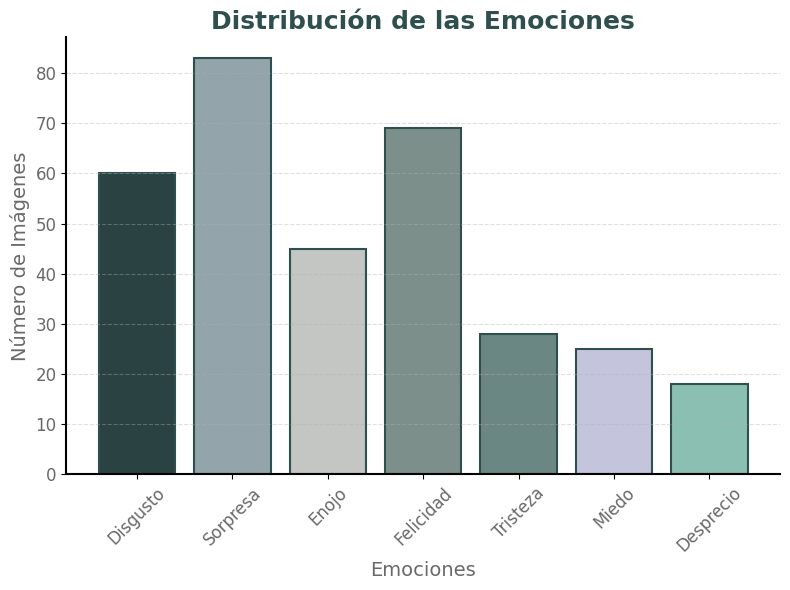

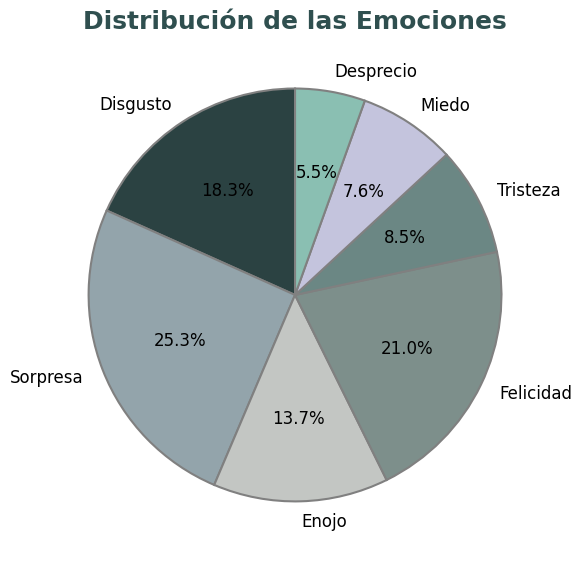

In [5]:
# Función para ordenar archivos numéricamente
def ordenar_numeros(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = map(int, partes[1::2])
    return partes

# Función para recolectar números de emoción desde archivos .txt
def recoger_datos_emocion(dir_raiz):
    datos = []
    for dirpath, dirnames, filenames in os.walk(dir_raiz):
        dirnames.sort(key=ordenar_numeros)
        filenames.sort()
        for archivo in filenames:
            if archivo.endswith('.txt'):
                ruta = os.path.join(dirpath, archivo)
                try:
                    with open(ruta, 'r') as f:
                        contenido = f.read().strip()
                        match = re.search(r'\d+', contenido)
                        if match:
                            numero = match.group(0)
                            datos.append(numero)
                except Exception as e:
                    print(f"Error leyendo {ruta}: {e}")
    return datos

# Guardar los números de emoción en un archivo
directorio_emociones = "Emotion"
datos_txt = recoger_datos_emocion(directorio_emociones)

if not datos_txt:
    print("No se encontraron archivos .txt en el directorio.")
else:
    with open('rutas_emociones.txt', 'w') as archivo:
        for numero in datos_txt:
            archivo.write(f"{numero}\n")
    print("Archivo 'rutas_emociones.txt' creado correctamente.")

# Leer los números de emoción desde el archivo
with open('rutas_emociones.txt', 'r') as f:
    numeros_emociones = [int(linea.strip()) for linea in f]

# Mapear los números a nombres de emociones
etiquetas_emocion = {
    0: 'Neutral',
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}
emociones = [etiquetas_emocion.get(num, 'Desconocido') for num in numeros_emociones]

# Contar la frecuencia de cada emoción
conteo_emociones = Counter(emociones)
print(conteo_emociones)

# Colores  para las gráficas
colores = ['#2B4242', '#93A4AB', '#C3C6C3', '#7D8F8B', '#6B8784', '#C4C4DD', '#8ABFB2', '#01332B']

# Gráfico de barras para la distribución de emociones
plt.figure(figsize=(8, 6))
barras = plt.bar(conteo_emociones.keys(), conteo_emociones.values(), color=colores)
plt.title('Distribución de las Emociones', fontsize=18, fontweight='bold', color='#2F4F4F')
plt.xlabel('Emociones', fontsize=14, color='#696969')
plt.ylabel('Número de Imágenes', fontsize=14, color='#696969')
plt.xticks(rotation=45, fontsize=12, color='#696969')
plt.yticks(fontsize=12, color='#696969')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# ajustar la apariencia del gráfico
for barra in barras:
    barra.set_edgecolor('#2F4F4F')
    barra.set_linewidth(1.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.tight_layout()
plt.show()

# Gráfico circular para la distribución de emociones
plt.figure(figsize=(6, 6))
plt.pie(conteo_emociones.values(), labels=conteo_emociones.keys(), autopct='%1.1f%%',
        colors=colores, startangle=90, wedgeprops={'edgecolor': 'gray', 'linewidth': 1.5},
        textprops={'fontsize': 12, 'color': 'black'})
plt.title('Distribución de las Emociones', fontsize=18, fontweight='bold', color='#2F4F4F')
plt.tight_layout()
plt.show()


# Análisis de Landmarks en Emociones

Este código realiza la detección y análisis de landmarks faciales para diferentes emociones en imágenes, y las visualiza tanto en 2D como en 3D. A continuación se describe cada parte del código:

## 1. Recolección de Datos
Se leen archivos `.txt` que contienen las emociones y se asocian con las imágenes correspondientes.

## 2. Detección de Landmarks
Utilizando `dlib`, se detectan los landmarks faciales de las imágenes y se ajustan centrando la nariz.

## 3. Visualización
- **Landmarks por Emoción**: Se visualizan los landmarks superpuestos para cada emoción.
- **Promedio de Landmarks**: Se grafican las posiciones promedio de los landmarks para cada emoción con conexiones faciales.
- **Gráfico 3D**: Se proyectan los landmarks promedio en 3D.


Error leyendo Emotion/S005/001/.ipynb_checkpoints/S005_001_00000011_emotion-checkpoint.txt: [Errno 2] No such file or directory: 'cohn-kanade-images/S005/001/.ipynb_checkpoints'
Emoción: Enojo
  Total de puntos: 3060
  Fuera de bigotes: Conteo = 85, Porcentaje = 2.78%
  Dentro de cuartiles: Conteo = 1001, Porcentaje = 32.71%
  En bigotes: Conteo = 1974, Porcentaje = 64.51%

Emoción: Desprecio
  Total de puntos: 1224
  Fuera de bigotes: Conteo = 46, Porcentaje = 3.76%
  Dentro de cuartiles: Conteo = 337, Porcentaje = 27.53%
  En bigotes: Conteo = 841, Porcentaje = 68.71%

Emoción: Disgusto
  Total de puntos: 4012
  Fuera de bigotes: Conteo = 157, Porcentaje = 3.91%
  Dentro de cuartiles: Conteo = 1273, Porcentaje = 31.73%
  En bigotes: Conteo = 2582, Porcentaje = 64.36%

Emoción: Miedo
  Total de puntos: 1700
  Fuera de bigotes: Conteo = 104, Porcentaje = 6.12%
  Dentro de cuartiles: Conteo = 598, Porcentaje = 35.18%
  En bigotes: Conteo = 998, Porcentaje = 58.71%

Emoción: Felicidad
  

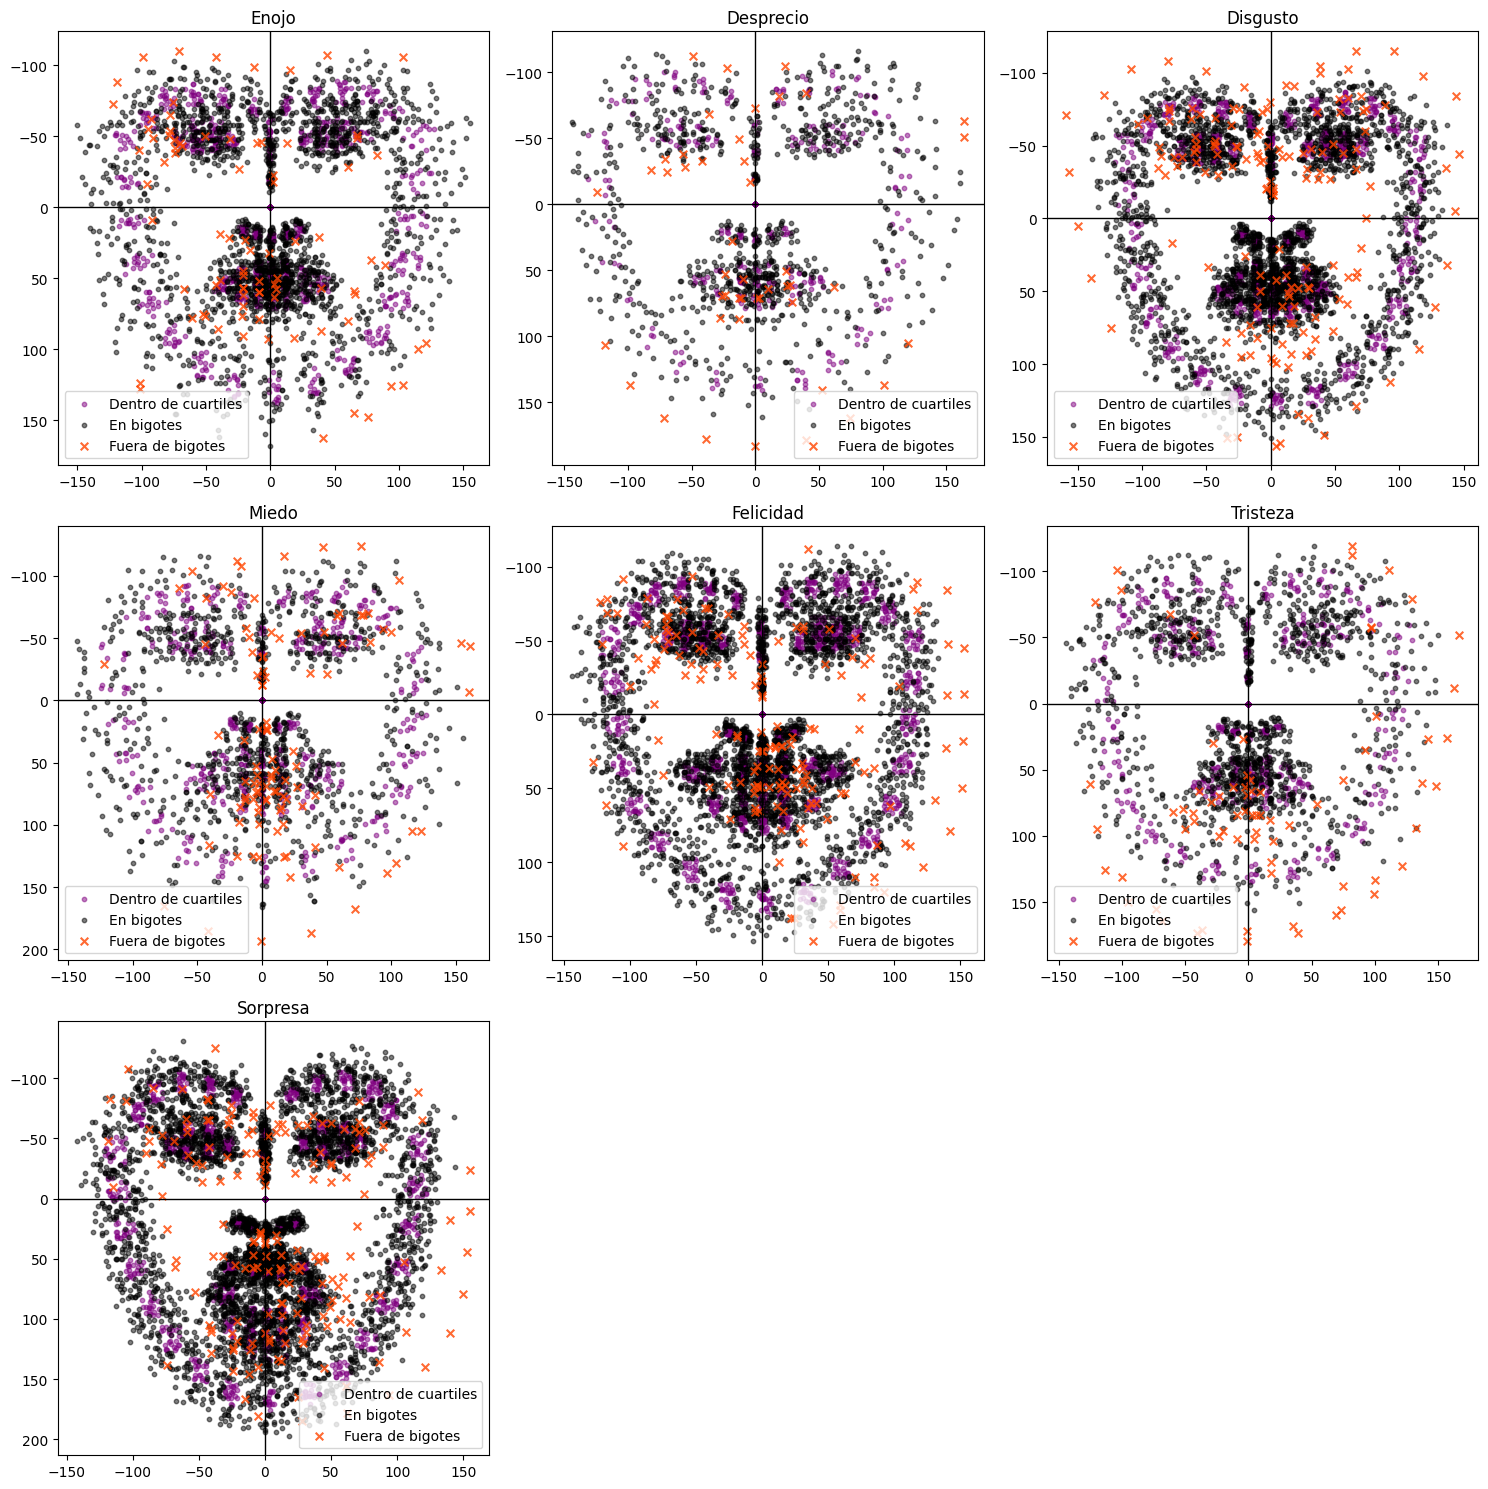

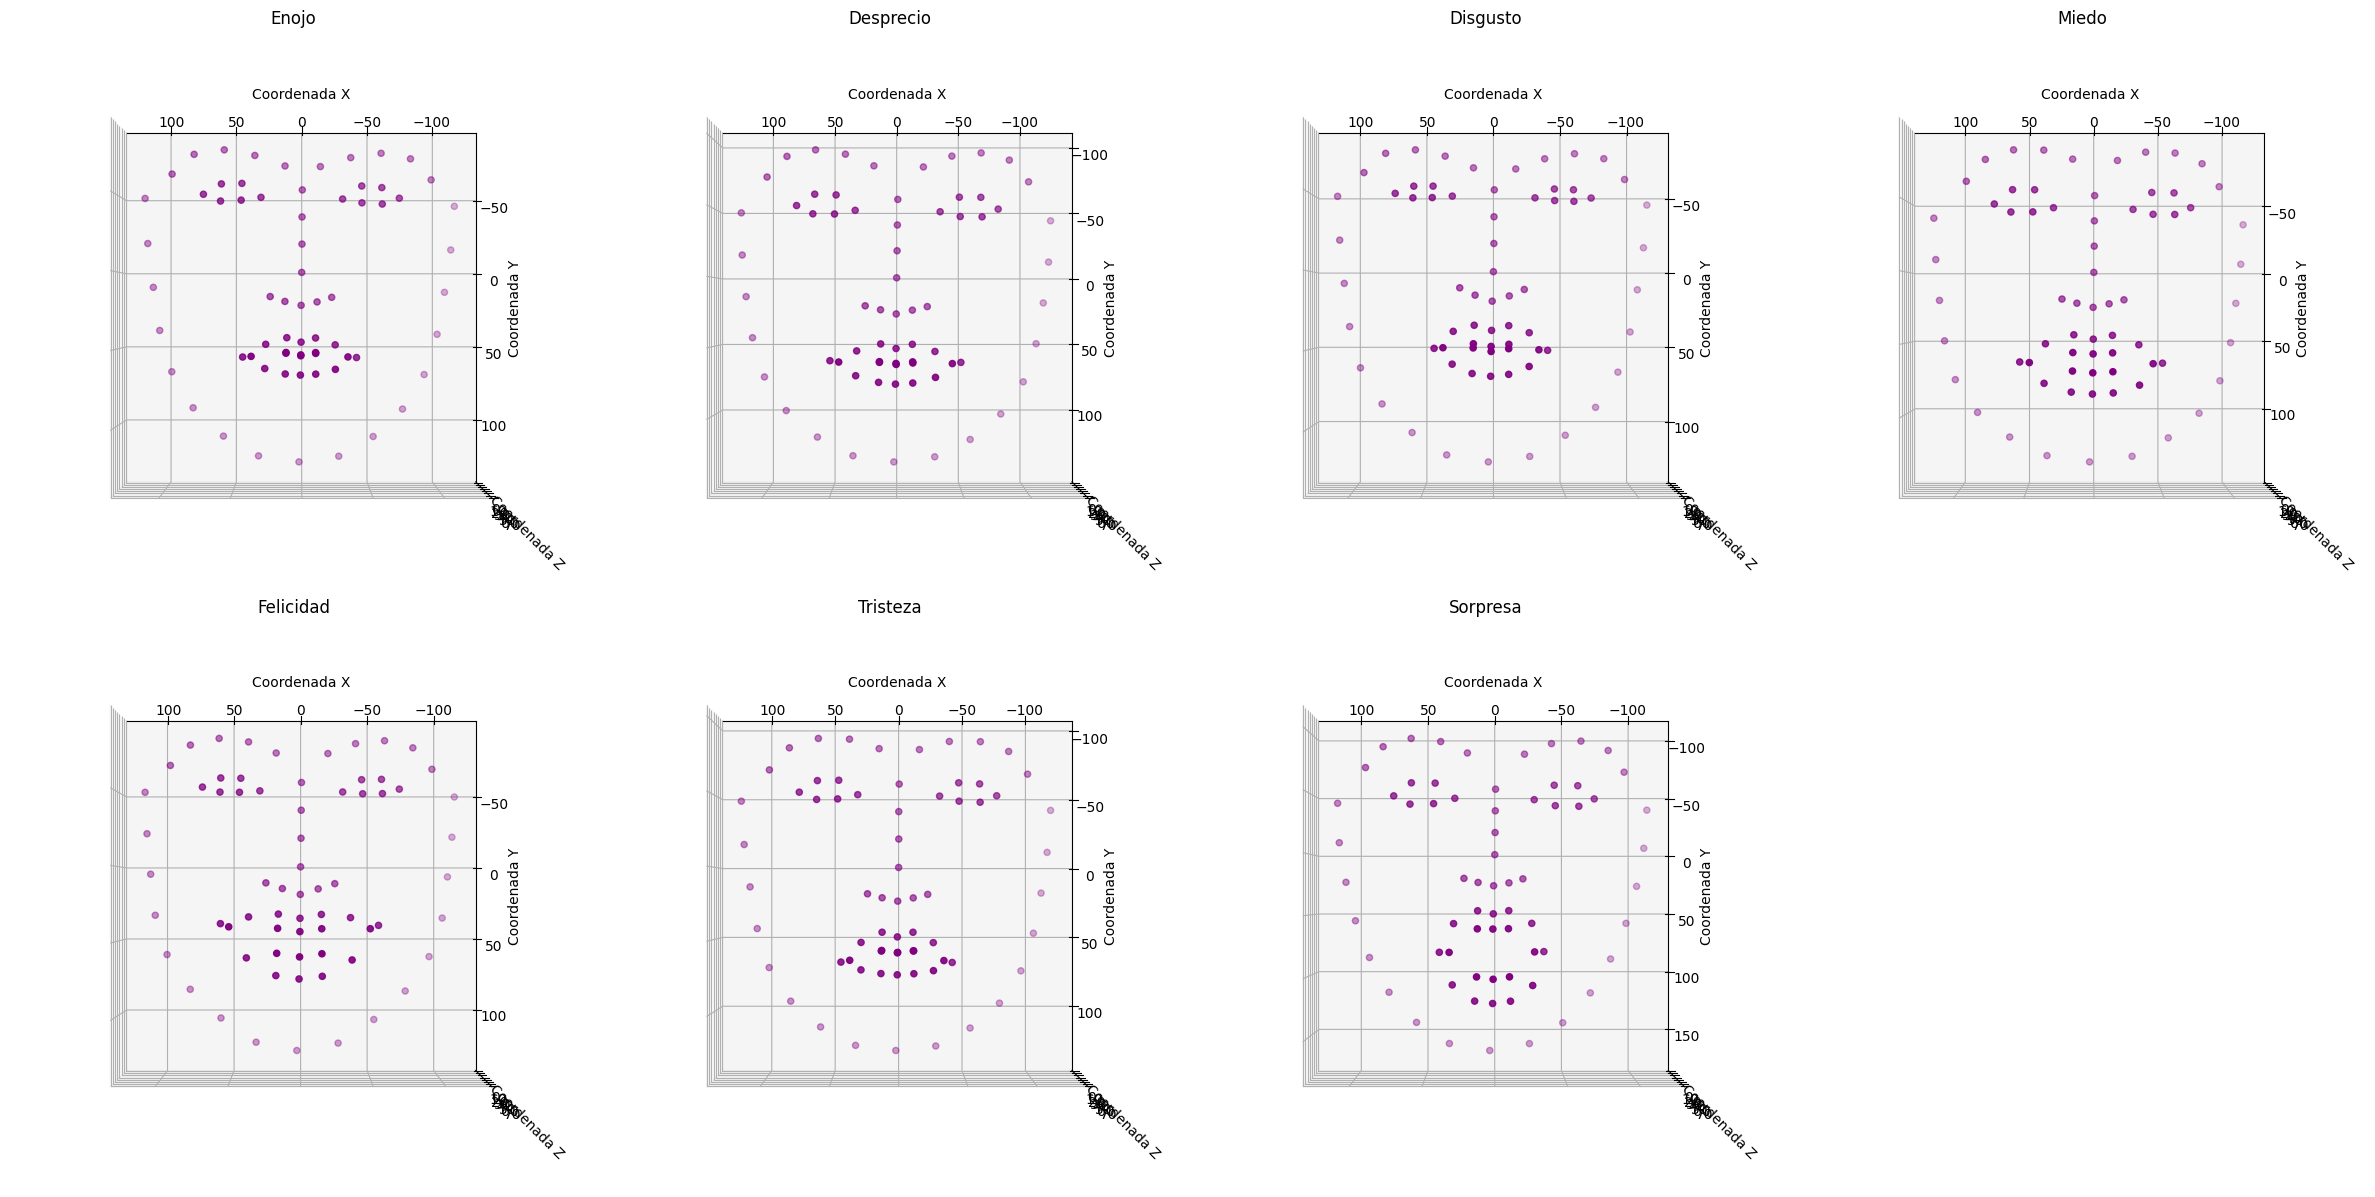

'\nimport os\nimport matplotlib.pyplot as plt\nimport numpy as np\n\ndef graf_pts_cat(pts_por_emo, cat_por_emo, output_dir="output_images"):\n    # Crear directorio de salida si no existe\n    os.makedirs(output_dir, exist_ok=True)\n\n    emos = [emo for emo, lst_pts in pts_por_emo.items() if lst_pts]\n    \n\n    \n\n    for emo in emos:\n        fig,ax =plt.subplots(figsize=(6,6))\n        \n        lst_pts = pts_por_emo[emo]\n        cats = cat_por_emo[emo]\n        arr_pts = np.array(lst_pts)\n\n        idx_dentro = np.where(cats == \'Dentro de cuartiles\')\n        idx_big = np.where(cats == \'En bigotes\')\n        idx_fuera = np.where(cats == \'Fuera de bigotes\')\n\n        coord_dentro = arr_pts[idx_dentro[0], idx_dentro[1], :]\n        coord_big = arr_pts[idx_big[0], idx_big[1], :]\n        coord_fuera = arr_pts[idx_fuera[0], idx_fuera[1], :]\n\n        ax.scatter(coord_dentro[:, 0], coord_dentro[:, 1], s=10, color=\'purple\', alpha=0.5, label=\'Dentro de cuartiles\')\n      

In [9]:
# Inicializar detector de rostros y predictor de puntos faciales
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Mapeo de números de emoción a nombres
emo_nom = {
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}

# de aquí
def ordenar_numerico(valor):
    # Ordenar cadenas numéricamente
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

def obtener_datos_txt(raiz):
    # Obtener rutas de imágenes y emociones desde archivos .txt
    datos = []
    for dir_actual, subdirs, archivos in os.walk(raiz):
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        for archivo in archivos:
            if archivo.endswith('.txt'):
                ruta_archivo = os.path.join(dir_actual, archivo)
                try:
                    with open(ruta_archivo, 'r') as f:
                        numero = f.read().strip()
                    try:
                        numero = int(float(numero))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_archivo}: {e}")
                        continue

                    # Construir ruta de imagen correspondiente
                    ruta_relativa = os.path.relpath(dir_actual, raiz)
                    dir_imagen = os.path.join('cohn-kanade-images', ruta_relativa)
                    archivos_imagen = [f for f in os.listdir(dir_imagen) if f.endswith('.png')]
                    archivos_imagen.sort(key=ordenar_numerico)
                    if archivos_imagen:
                        ruta_imagen = os.path.join(dir_imagen, archivos_imagen[-1])  # Última imagen
                        datos.append((ruta_imagen, numero))  # Añadir ruta de imagen y emoción
                    else:
                        print(f"No se encontraron imágenes en {dir_imagen}")
                except Exception as e:
                    print(f"Error leyendo {ruta_archivo}: {e}")
    return datos

def extraer_puntos(ruta_imagen):
    # Extraer puntos faciales de una imagen
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos

def centrar_puntos(puntos):
    # Centrar puntos faciales en la nariz
    nariz = puntos[30]  # Índice 30 corresponde a la nariz
    puntos_centrados = [(x - nariz[0], y - nariz[1]) for x, y in puntos]
    return puntos_centrados

def calcular_categorias_puntos(puntos_por_emocion):
    # Calcular categorías de puntos y estadísticas por emoción
    categorias_por_emocion = {}
    stats_por_emocion = {}

    for emocion, lista_puntos in puntos_por_emocion.items():
        if lista_puntos:
            array_puntos = np.array(lista_puntos)
            Q1 = np.percentile(array_puntos, 25, axis=0)
            Q3 = np.percentile(array_puntos, 75, axis=0)
            IQR = Q3 - Q1  # Rango intercuartílico

            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            outliers = (array_puntos < limite_inferior) | (array_puntos > limite_superior)
            dentro = (array_puntos >= Q1) & (array_puntos <= Q3)

            mascara_outliers = outliers.any(axis=2)
            mascara_dentro = dentro.all(axis=2)
            mascara_bigotes = (~mascara_outliers) & (~mascara_dentro)

            categorias = np.empty((array_puntos.shape[0], array_puntos.shape[1]), dtype=object)
            categorias[mascara_outliers] = 'Fuera de bigotes'
            categorias[mascara_dentro] = 'Dentro de cuartiles'
            categorias[mascara_bigotes] = 'En bigotes'

            categorias_por_emocion[emocion] = categorias

            # Calcular conteos y porcentajes
            total_puntos = array_puntos.size // 2  # Total de puntos (cada punto tiene x e y)
            num_fuera = np.sum(mascara_outliers)
            num_dentro = np.sum(mascara_dentro)
            num_bigotes = np.sum(mascara_bigotes)

            porcentaje_fuera = (num_fuera / total_puntos) * 100
            porcentaje_dentro = (num_dentro / total_puntos) * 100
            porcentaje_bigotes = (num_bigotes / total_puntos) * 100

            stats_por_emocion[emocion] = {
                'Total Puntos': total_puntos,
                'Fuera de bigotes': {'Conteo': num_fuera, 'Porcentaje': porcentaje_fuera},
                'Dentro de cuartiles': {'Conteo': num_dentro, 'Porcentaje': porcentaje_dentro},
                'En bigotes': {'Conteo': num_bigotes, 'Porcentaje': porcentaje_bigotes}
            }

    return categorias_por_emocion, stats_por_emocion
# hasta aquí vuelve a el nombre de las variables originales

def prom_pts(pts_por_emo):
    # Calcular promedio de puntos por emoción
    proms = {}
    for emo, lst_pts in pts_por_emo.items():
        if lst_pts:
            arr_pts = np.array(lst_pts)
            promedio = np.mean(arr_pts, axis=0)
            proms[emo] = promedio
    return proms

def graf_prom_pts_3d(proms):
    # Graficar promedios de puntos en 3D por emoción
    emos = list(proms.keys())
    num_emos = len(emos)
    n_cols = 4
    n_rows = (num_emos + n_cols - 1) // n_cols

    fig = plt.figure(figsize=(n_cols * 6, n_rows * 6))

    for idx, emo in enumerate(emos):
        promedio = proms[emo]
        xs = promedio[:, 0]
        ys = promedio[:, 1]
        zs = np.arange(68)

        ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
        ax.scatter(xs, ys, zs, color='purple', s=20)

        ax.set_title(f'{emo_nom.get(emo, emo)}', fontsize=12)
        ax.set_xlabel('Coordenada X')
        ax.set_ylabel('Coordenada Y')
        ax.set_zlabel('Coordenada Z')
        ax.view_init(elev=90, azim=90)

    plt.tight_layout()
    plt.show()

def graf_pts_cat(pts_por_emo, cat_por_emo):
    # Graficar puntos con categorías en subplots por emoción
    emos = [emo for emo, lst_pts in pts_por_emo.items() if lst_pts]
    num_emos = len(emos)
    n_cols = 3
    n_rows = (num_emos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes = axes.flatten()

    for idx, (emo, ax) in enumerate(zip(emos, axes)):
        lst_pts = pts_por_emo[emo]
        cats = cat_por_emo[emo]
        arr_pts = np.array(lst_pts)

        idx_dentro = np.where(cats == 'Dentro de cuartiles')
        idx_big = np.where(cats == 'En bigotes')
        idx_fuera = np.where(cats == 'Fuera de bigotes')

        coord_dentro = arr_pts[idx_dentro[0], idx_dentro[1], :]
        coord_big = arr_pts[idx_big[0], idx_big[1], :]
        coord_fuera = arr_pts[idx_fuera[0], idx_fuera[1], :]

        ax.scatter(coord_dentro[:, 0], coord_dentro[:, 1], s=10, color='purple', alpha=0.5, label='Dentro de cuartiles')
        ax.scatter(coord_big[:, 0], coord_big[:, 1], s=10, color='black', alpha=0.5, label='En bigotes')
        ax.scatter(coord_fuera[:, 0], coord_fuera[:, 1], s=30, color='Orangered', alpha=0.8, label='Fuera de bigotes', marker='x')

        ax.invert_yaxis()
        ax.axhline(0, color='black', linewidth=1)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(f"{emo_nom.get(emo, emo)}")
        ax.legend()

    for idx in range(num_emos, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# Directorio de emociones e imágenes
dir_emo = "Emotion"
datos_txt = obtener_datos_txt(dir_emo)

if datos_txt:
    pts_por_emo = {i: [] for i in range(1, 8)}

    for ruta_img, emo in datos_txt:
        pts = extraer_puntos(ruta_img)
        if pts:
            pts_cen = centrar_puntos(pts)
            pts_por_emo[emo].append(pts_cen)

    pts_por_emo = {k: v for k, v in pts_por_emo.items() if v}

    cat_por_emo, stats_por_emo = calcular_categorias_puntos(pts_por_emo)

    for emo, stats in stats_por_emo.items():
        print(f"Emoción: {emo_nom.get(emo, emo)}")
        print(f"  Total de puntos: {stats['Total Puntos']}")
        for categoria, valores in stats.items():
            if categoria != 'Total Puntos':
                print(f"  {categoria}: Conteo = {valores['Conteo']}, Porcentaje = {valores['Porcentaje']:.2f}%")
        print()

    graf_pts_cat(pts_por_emo, cat_por_emo)

    proms = prom_pts(pts_por_emo)

    graf_prom_pts_3d(proms)
else:
    print("No se encontraron datos de emociones para procesar.")

"""
import os
import matplotlib.pyplot as plt
import numpy as np

def graf_pts_cat(pts_por_emo, cat_por_emo, output_dir="output_images"):
    # Crear directorio de salida si no existe
    os.makedirs(output_dir, exist_ok=True)

    emos = [emo for emo, lst_pts in pts_por_emo.items() if lst_pts]
    

    

    for emo in emos:
        fig,ax =plt.subplots(figsize=(6,6))
        
        lst_pts = pts_por_emo[emo]
        cats = cat_por_emo[emo]
        arr_pts = np.array(lst_pts)

        idx_dentro = np.where(cats == 'Dentro de cuartiles')
        idx_big = np.where(cats == 'En bigotes')
        idx_fuera = np.where(cats == 'Fuera de bigotes')

        coord_dentro = arr_pts[idx_dentro[0], idx_dentro[1], :]
        coord_big = arr_pts[idx_big[0], idx_big[1], :]
        coord_fuera = arr_pts[idx_fuera[0], idx_fuera[1], :]

        ax.scatter(coord_dentro[:, 0], coord_dentro[:, 1], s=10, color='purple', alpha=0.5, label='Dentro de cuartiles')
        ax.scatter(coord_big[:, 0], coord_big[:, 1], s=10, color='black', alpha=0.5, label='En bigotes')
        ax.scatter(coord_fuera[:, 0], coord_fuera[:, 1], s=30, color='Orangered', alpha=0.8, label='Fuera de bigotes', marker='x')

        ax.invert_yaxis()
        ax.axhline(0, color='black', linewidth=1)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(f"{emo_nom.get(emo, emo)}")
        ax.legend()

        # Guardar imagen individualmente
        file_path = os.path.join(output_dir, f"{emo_nom.get(emo, emo)}.png")
        print(f"Guardando imagen: {file_path}")  # Mensaje de depuración
        fig.savefig(file_path, dpi=300, bbox_inches='tight')



    # Cerrar la figura principal para evitar consumo de memoria
    plt.close(fig)

    print(f"✅ Todas las imágenes se han guardado en '{output_dir}'")

# Llamada a la función para probar
graf_pts_cat(pts_por_emo, cat_por_emo)
"""


Error leyendo Emotion/S005/001/.ipynb_checkpoints/S005_001_00000011_emotion-checkpoint.txt: [Errno 2] No such file or directory: 'cohn-kanade-images/S005/001/.ipynb_checkpoints'
Emoción: Enojo
  Total de puntos: 3060
  Fuera de bigotes: Conteo = 85, Porcentaje = 2.78%
  Dentro de cuartiles: Conteo = 1001, Porcentaje = 32.71%
  En bigotes: Conteo = 1974, Porcentaje = 64.51%

Emoción: Desprecio
  Total de puntos: 1224
  Fuera de bigotes: Conteo = 46, Porcentaje = 3.76%
  Dentro de cuartiles: Conteo = 337, Porcentaje = 27.53%
  En bigotes: Conteo = 841, Porcentaje = 68.71%

Emoción: Disgusto
  Total de puntos: 4012
  Fuera de bigotes: Conteo = 157, Porcentaje = 3.91%
  Dentro de cuartiles: Conteo = 1273, Porcentaje = 31.73%
  En bigotes: Conteo = 2582, Porcentaje = 64.36%

Emoción: Miedo
  Total de puntos: 1700
  Fuera de bigotes: Conteo = 104, Porcentaje = 6.12%
  Dentro de cuartiles: Conteo = 598, Porcentaje = 35.18%
  En bigotes: Conteo = 998, Porcentaje = 58.71%

Emoción: Felicidad
  

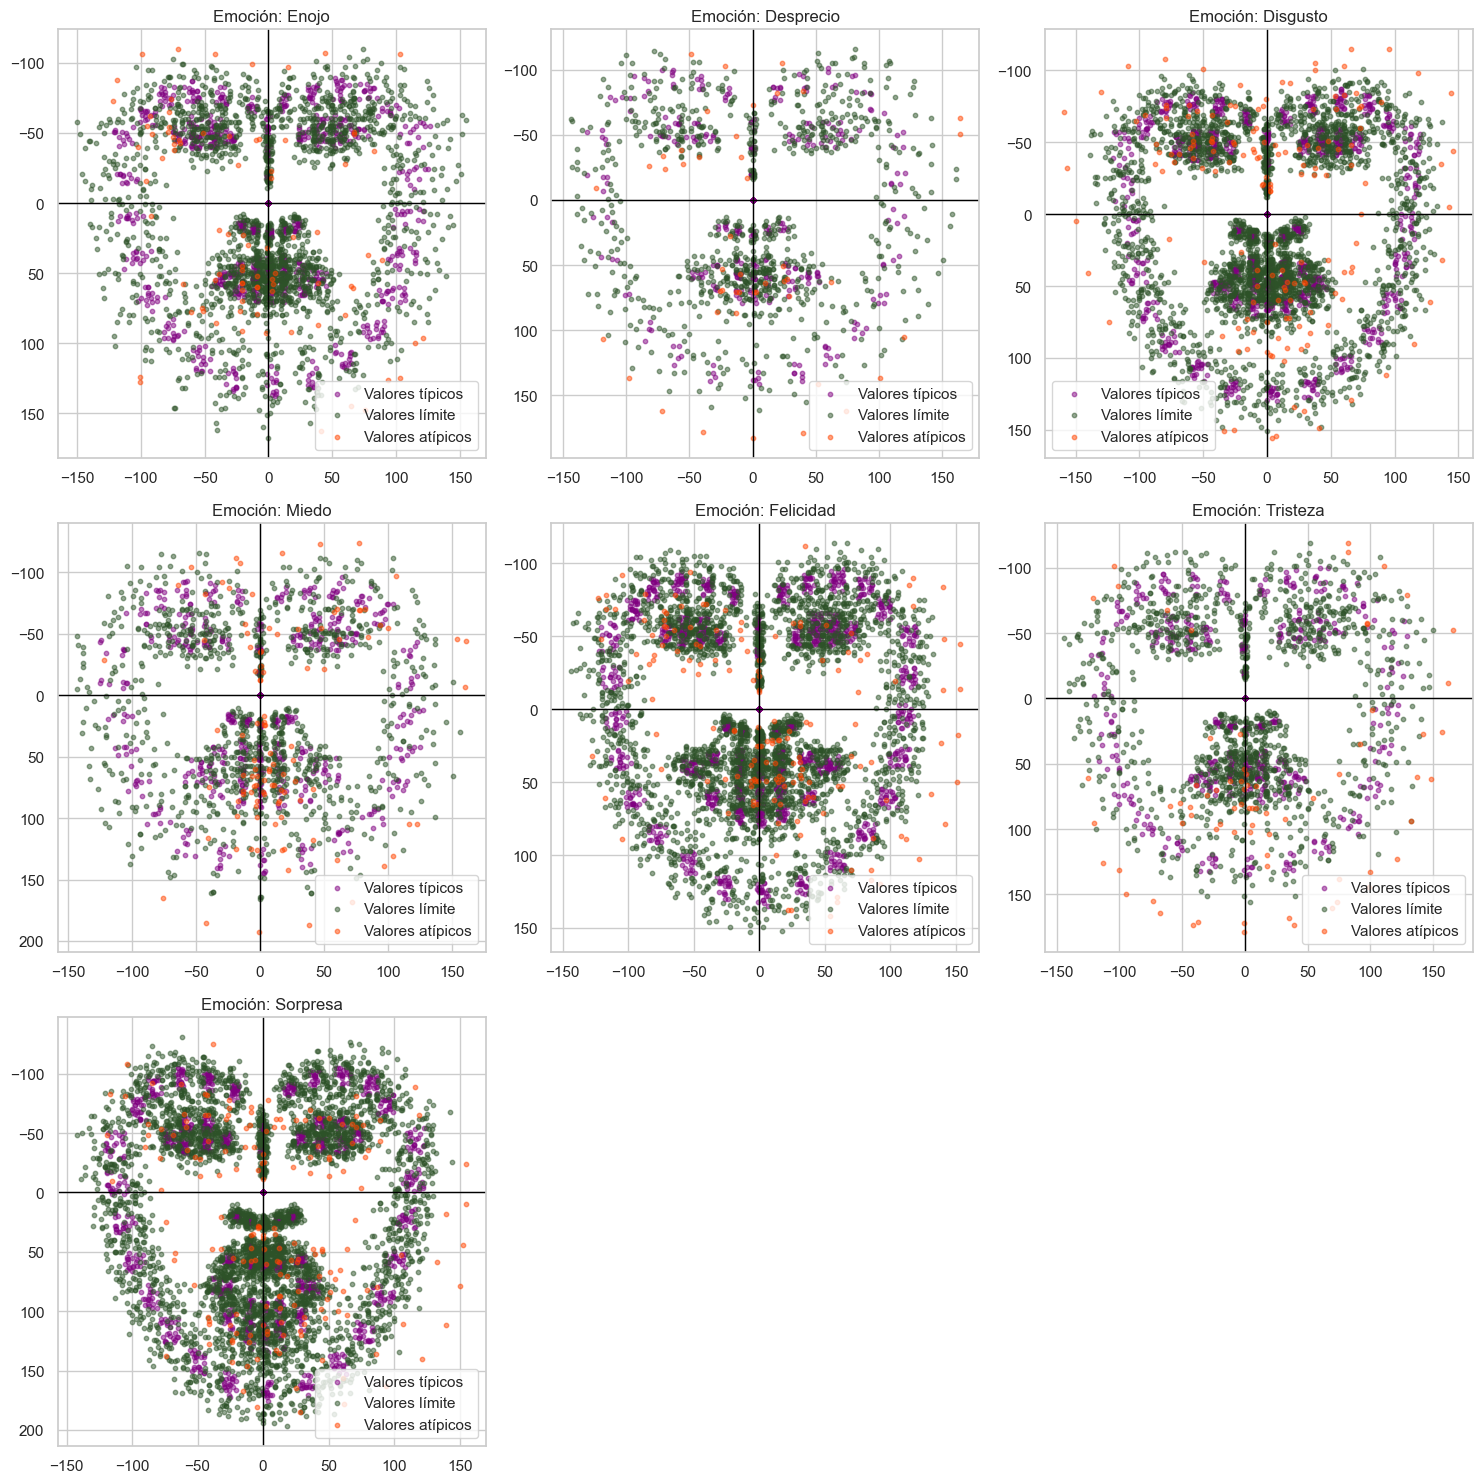

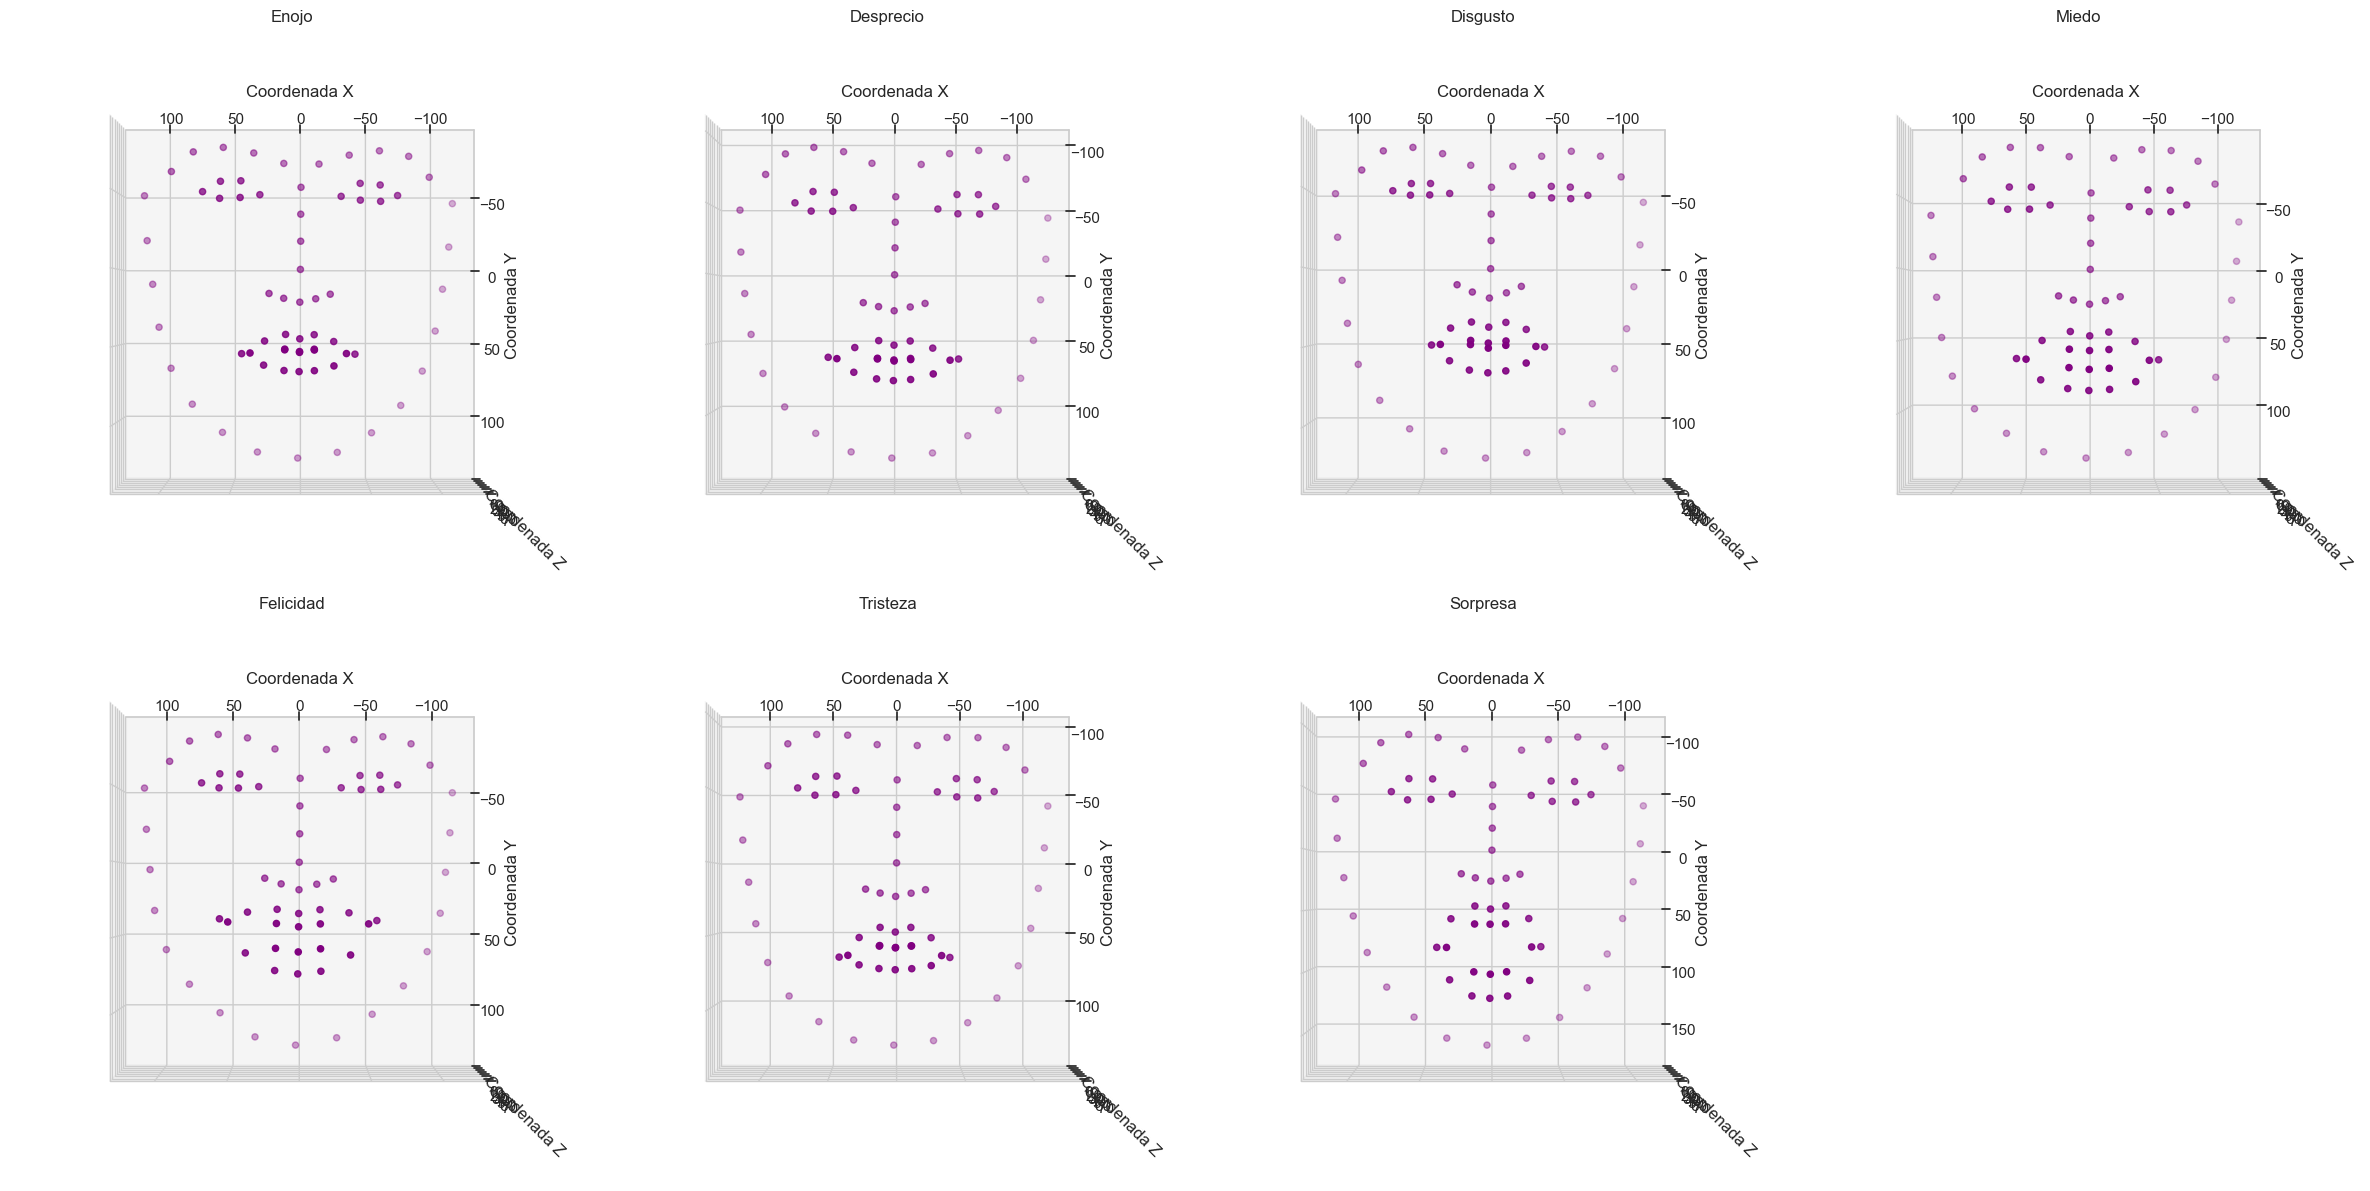

In [7]:
# Inicializar detector de rostros y predictor de puntos faciales
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Mapeo de números de emoción a nombres
emo_nom = {
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}

# de aquí
def ordenar_numerico(valor):
    # Ordenar cadenas numéricamente
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

def obtener_datos_txt(raiz):
    # Obtener rutas de imágenes y emociones desde archivos .txt
    datos = []
    for dir_actual, subdirs, archivos in os.walk(raiz):
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        for archivo in archivos:
            if archivo.endswith('.txt'):
                ruta_archivo = os.path.join(dir_actual, archivo)
                try:
                    with open(ruta_archivo, 'r') as f:
                        numero = f.read().strip()
                    try:
                        numero = int(float(numero))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_archivo}: {e}")
                        continue

                    # Construir ruta de imagen correspondiente
                    ruta_relativa = os.path.relpath(dir_actual, raiz)
                    dir_imagen = os.path.join('cohn-kanade-images', ruta_relativa)
                    archivos_imagen = [f for f in os.listdir(dir_imagen) if f.endswith('.png')]
                    archivos_imagen.sort(key=ordenar_numerico)
                    if archivos_imagen:
                        ruta_imagen = os.path.join(dir_imagen, archivos_imagen[-1])  # Última imagen
                        datos.append((ruta_imagen, numero))  # Añadir ruta de imagen y emoción
                    else:
                        print(f"No se encontraron imágenes en {dir_imagen}")
                except Exception as e:
                    print(f"Error leyendo {ruta_archivo}: {e}")
    return datos

def extraer_puntos(ruta_imagen):
    # Extraer puntos faciales de una imagen
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos

def centrar_puntos(puntos):
    # Centrar puntos faciales en la nariz
    nariz = puntos[30]  # Índice 30 corresponde a la nariz
    puntos_centrados = [(x - nariz[0], y - nariz[1]) for x, y in puntos]
    return puntos_centrados

def calcular_categorias_puntos(puntos_por_emocion):
    # Calcular categorías de puntos y estadísticas por emoción
    categorias_por_emocion = {}
    stats_por_emocion = {}

    for emocion, lista_puntos in puntos_por_emocion.items():
        if lista_puntos:
            array_puntos = np.array(lista_puntos)
            Q1 = np.percentile(array_puntos, 25, axis=0)
            Q3 = np.percentile(array_puntos, 75, axis=0)
            IQR = Q3 - Q1  # Rango intercuartílico

            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            outliers = (array_puntos < limite_inferior) | (array_puntos > limite_superior)
            dentro = (array_puntos >= Q1) & (array_puntos <= Q3)

            mascara_outliers = outliers.any(axis=2)
            mascara_dentro = dentro.all(axis=2)
            mascara_bigotes = (~mascara_outliers) & (~mascara_dentro)

            categorias = np.empty((array_puntos.shape[0], array_puntos.shape[1]), dtype=object)
            categorias[mascara_outliers] = 'Fuera de bigotes'
            categorias[mascara_dentro] = 'Dentro de cuartiles'
            categorias[mascara_bigotes] = 'En bigotes'

            categorias_por_emocion[emocion] = categorias

            # Calcular conteos y porcentajes
            total_puntos = array_puntos.size // 2  # Total de puntos (cada punto tiene x e y)
            num_fuera = np.sum(mascara_outliers)
            num_dentro = np.sum(mascara_dentro)
            num_bigotes = np.sum(mascara_bigotes)

            porcentaje_fuera = (num_fuera / total_puntos) * 100
            porcentaje_dentro = (num_dentro / total_puntos) * 100
            porcentaje_bigotes = (num_bigotes / total_puntos) * 100

            stats_por_emocion[emocion] = {
                'Total Puntos': total_puntos,
                'Fuera de bigotes': {'Conteo': num_fuera, 'Porcentaje': porcentaje_fuera},
                'Dentro de cuartiles': {'Conteo': num_dentro, 'Porcentaje': porcentaje_dentro},
                'En bigotes': {'Conteo': num_bigotes, 'Porcentaje': porcentaje_bigotes}
            }

    return categorias_por_emocion, stats_por_emocion
# hasta aquí vuelve a el nombre de las variables originales

def prom_pts(pts_por_emo):
    # Calcular promedio de puntos por emoción
    proms = {}
    for emo, lst_pts in pts_por_emo.items():
        if lst_pts:
            arr_pts = np.array(lst_pts)
            promedio = np.mean(arr_pts, axis=0)
            proms[emo] = promedio
    return proms

def graf_prom_pts_3d(proms):
    # Graficar promedios de puntos en 3D por emoción
    emos = list(proms.keys())
    num_emos = len(emos)
    n_cols = 4
    n_rows = (num_emos + n_cols - 1) // n_cols

    fig = plt.figure(figsize=(n_cols * 6, n_rows * 6))

    for idx, emo in enumerate(emos):
        promedio = proms[emo]
        xs = promedio[:, 0]
        ys = promedio[:, 1]
        zs = np.arange(68)

        ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
        ax.scatter(xs, ys, zs, color='purple', s=20)

        ax.set_title(f'{emo_nom.get(emo, emo)}', fontsize=12)
        ax.set_xlabel('Coordenada X')
        ax.set_ylabel('Coordenada Y')
        ax.set_zlabel('Coordenada Z')
        ax.view_init(elev=90, azim=90)

    plt.tight_layout()
    plt.show()

def graf_pts_cat(pts_por_emo, cat_por_emo):
    # Graficar puntos con categorías en subplots por emoción
    emos = [emo for emo, lst_pts in pts_por_emo.items() if lst_pts]
    num_emos = len(emos)
    n_cols = 3
    n_rows = (num_emos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes = axes.flatten()

    for idx, (emo, ax) in enumerate(zip(emos, axes)):
        lst_pts = pts_por_emo[emo]
        cats = cat_por_emo[emo]
        arr_pts = np.array(lst_pts)

        idx_dentro = np.where(cats == 'Dentro de cuartiles')
        idx_big = np.where(cats == 'En bigotes')
        idx_fuera = np.where(cats == 'Fuera de bigotes')

        coord_dentro = arr_pts[idx_dentro[0], idx_dentro[1], :]
        coord_big = arr_pts[idx_big[0], idx_big[1], :]
        coord_fuera = arr_pts[idx_fuera[0], idx_fuera[1], :]

        ax.scatter(coord_dentro[:, 0], coord_dentro[:, 1], s=10, color='purple', alpha=0.5, label='Valores típicos')
        ax.scatter(coord_big[:, 0], coord_big[:, 1], s=10, color='#2D5228', alpha=0.5, label='Valores límite')
        ax.scatter(coord_fuera[:, 0], coord_fuera[:, 1], s=10, color='Orangered', alpha=0.5, label='Valores atípicos')

        ax.invert_yaxis()
        ax.axhline(0, color='black', linewidth=1)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(f"Emoción: {emo_nom.get(emo, emo)}")
        ax.legend()

    for idx in range(num_emos, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# Directorio de emociones e imágenes
dir_emo = "Emotion"
datos_txt = obtener_datos_txt(dir_emo)

if datos_txt:
    pts_por_emo = {i: [] for i in range(1, 8)}

    for ruta_img, emo in datos_txt:
        pts = extraer_puntos(ruta_img)
        if pts:
            pts_cen = centrar_puntos(pts)
            pts_por_emo[emo].append(pts_cen)

    pts_por_emo = {k: v for k, v in pts_por_emo.items() if v}

    cat_por_emo, stats_por_emo = calcular_categorias_puntos(pts_por_emo)

    for emo, stats in stats_por_emo.items():
        print(f"Emoción: {emo_nom.get(emo, emo)}")
        print(f"  Total de puntos: {stats['Total Puntos']}")
        for categoria, valores in stats.items():
            if categoria != 'Total Puntos':
                print(f"  {categoria}: Conteo = {valores['Conteo']}, Porcentaje = {valores['Porcentaje']:.2f}%")
        print()

    graf_pts_cat(pts_por_emo, cat_por_emo)

    proms = prom_pts(pts_por_emo)

    graf_prom_pts_3d(proms)
else:
    print("No se encontraron datos de emociones para procesar.")



## Descripción del Código para Análisis de Emociones con Landmarks Faciales

### Configuración y Herramientas
- **Estilo de Seaborn**: Configura `whitegrid` para una visualización clara.
- **Detección de Rostros y Landmarks**: Utiliza `dlib` para identificar rostros y extraer landmarks faciales.

### Funciones Principales
- **Ordenación y Lectura de Datos**: Lee y ordena archivos `.txt` para extraer emociones y rutas de imágenes asociadas.
- **Extracción de Landmarks**: Detecta rostros y extrae landmarks usando `dlib`.
- **Normalización de Landmarks**: Ajusta los landmarks al centro de la nariz y normaliza sus movimientos usando Min-Max Scaling.
- **Análisis de Movimientos**: Calcula los movimientos de los landmarks entre imágenes consecutivas para cada emoción, agrupa estos datos y calcula promedios.

### Visualización
- **Gráficos de Landmarks y Movimientos**: Presenta gráficos que comparan posiciones iniciales y finales de landmarks, destacando los movimientos más significativos y la variabilidad por cada emoción.

### Ejecución
- **Procesamiento de Datos**: Extrae y procesa datos del directorio `Emotion`, verifica disponibilidad de datos, y ejecuta visualizaciones.

Este código facilita el estudio de las variaciones en la expresión facial asociadas a emociones específicas.


No se encontraron imágenes en cohn-kanade-images/S005/001/.ipynb_checkpoints


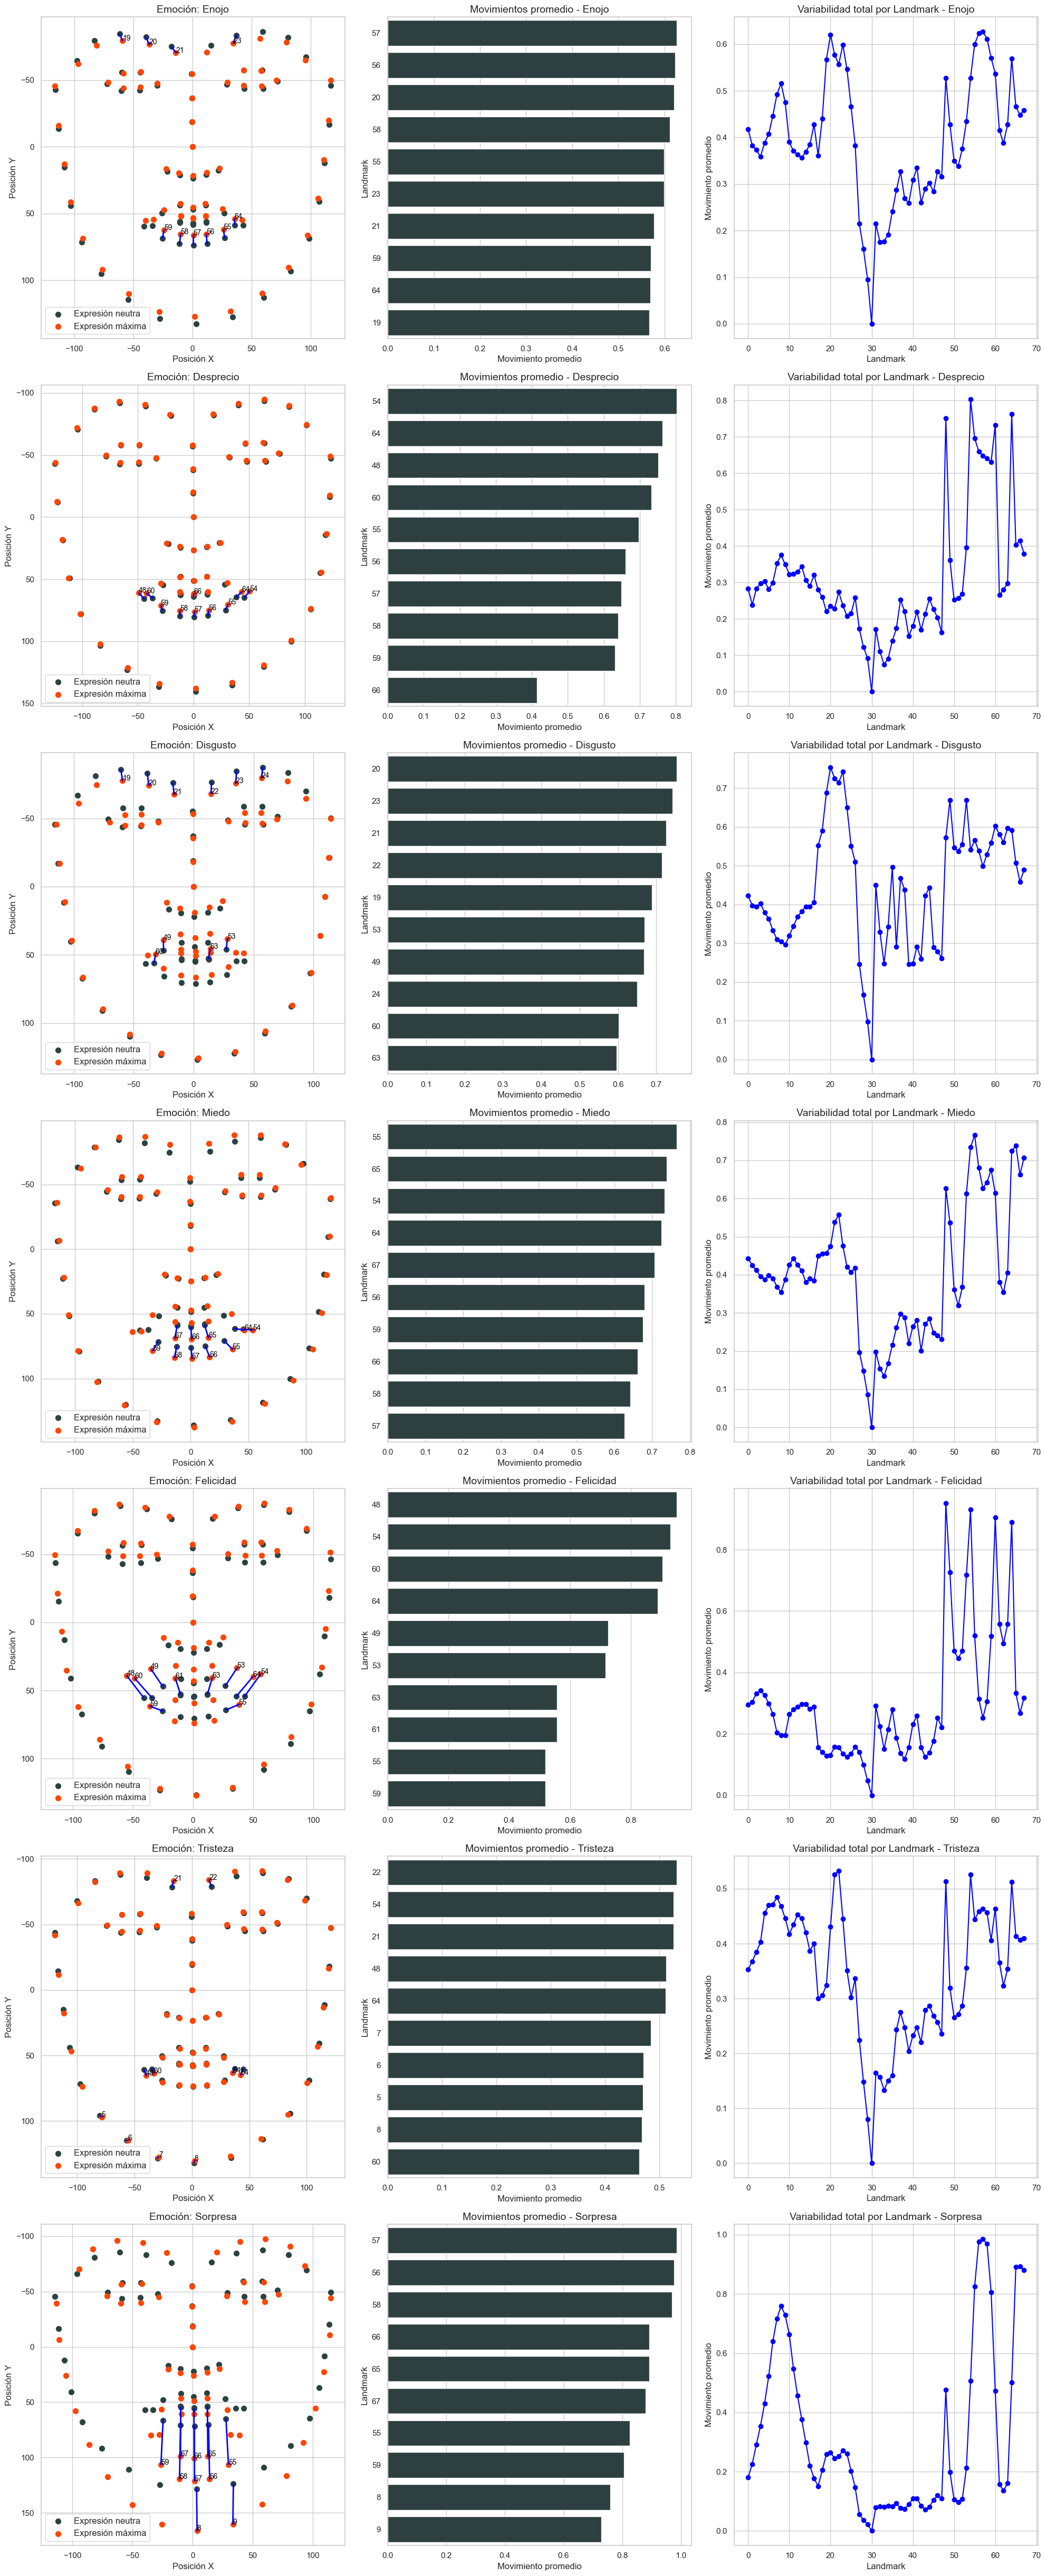

In [6]:
# Configurar estilo de Seaborn
sns.set(style="whitegrid")

# Inicializar el detector de rostros y el predictor de landmarks
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")  # Ruta del predictor

# Mapeo de emociones
emociones = {
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}

# Función para ordenar numéricamente los archivos
def ordenar_numerico(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

# Leer archivos .txt y obtener rutas de la primera y última imagen y la emoción
def obtener_datos_txt(raiz):
    datos = []
    for dirpath, dirnames, filenames in os.walk(raiz):
        dirnames.sort(key=ordenar_numerico)
        filenames.sort()
        for filename in filenames:
            if filename.endswith('.txt'):
                filepath = os.path.join(dirpath, filename)
                try:
                    with open(filepath, 'r') as f:
                        emocion = int(float(f.read().strip()))  # Leer la emoción
                    
                    dir_secuencia = dirpath.replace('Emotion', 'cohn-kanade-images')
                    imagenes = sorted(glob.glob(os.path.join(dir_secuencia, '*.png')), key=ordenar_numerico)
                    
                    if imagenes:
                        img_primera = imagenes[0]
                        img_ultima = imagenes[-1]
                        datos.append((img_primera, img_ultima, emocion))
                    else:
                        print(f"No se encontraron imágenes en {dir_secuencia}")
                except Exception as e:
                    print(f"Error leyendo {filepath}: {e}")
    return datos

def obtener_landmarks(ruta_img):
    img = cv2.imread(ruta_img)
    if img is None:
        print(f"No se pudo cargar la imagen {ruta_img}")
        return None

    # Utilizar la imagen directamente en el detector de rostros
    rostros = detector(img)
    if len(rostros) == 0:
        return None

    for rostro in rostros:
        landmarks = predictor(img, rostro)
        puntos = np.array([(landmarks.part(n).x, landmarks.part(n).y) for n in range(68)])
        return puntos


# Ajustar landmarks para centrar la nariz
def ajustar_landmarks_nariz(landmarks):
    nariz = landmarks[30]
    landmarks_ajustados = landmarks - nariz
    return landmarks_ajustados
    
# Función para estandarizar los movimientos usando Min-Max Scaling
def estandarizar_min_max(datos):
    minimo = np.min(datos, axis=0)
    maximo = np.max(datos, axis=0)
    return (datos - minimo) / (maximo - minimo)

# Calcular el movimiento de cada landmark y estandarizarlo
def calcular_movimiento(landmarks1, landmarks2):
    movimientos = np.linalg.norm(landmarks2 - landmarks1, axis=1)
    movimientos_estandarizados = estandarizar_min_max(movimientos)
    return movimientos_estandarizados

# Procesar los movimientos de los landmarks
def procesar_movimientos_landmarks(datos_txt):
    movs_emociones = {i: [] for i in range(1, 8)}  # Movimientos por emoción
    landmarks_primera = {i: [] for i in range(1, 8)}  # Landmarks primera imagen
    landmarks_ultima = {i: [] for i in range(1, 8)}  # Landmarks última imagen

    for img_primera, img_ultima, emocion in datos_txt:
        lmarks_primera = obtener_landmarks(img_primera)
        lmarks_ultima = obtener_landmarks(img_ultima)

        if lmarks_primera is not None and lmarks_ultima is not None:
            lmarks_prim_ajustados = ajustar_landmarks_nariz(lmarks_primera)
            lmarks_ult_ajustados = ajustar_landmarks_nariz(lmarks_ultima)

            movimientos = calcular_movimiento(lmarks_prim_ajustados, lmarks_ult_ajustados)

            movs_emociones[emocion].append(movimientos)
            landmarks_primera[emocion].append(lmarks_prim_ajustados)
            landmarks_ultima[emocion].append(lmarks_ult_ajustados)

    # Cálculo de promedios
    prom_movimientos = {emocion: np.mean(movs_emociones[emocion], axis=0) for emocion in range(1, 8) if movs_emociones[emocion]}
    prom_landmarks_primera = {emocion: np.mean(landmarks_primera[emocion], axis=0) for emocion in range(1, 8) if landmarks_primera[emocion]}
    prom_landmarks_ultima = {emocion: np.mean(landmarks_ultima[emocion], axis=0) for emocion in range(1, 8) if landmarks_ultima[emocion]}

    # Crear las figuras y ajustar tamaño
    num_emociones = len(prom_movimientos)
    fig, axes = plt.subplots(num_emociones, 3, figsize=(20, 7 * num_emociones))  # Hacer más largas las imágenes

    if num_emociones == 1:
        axes = [axes]

    for idx, emocion in enumerate(sorted(prom_movimientos.keys())):
        promedio_movimientos = prom_movimientos[emocion]
        top_landmarks = np.argsort(promedio_movimientos)[-10:][::-1]

        promedio_primera = prom_landmarks_primera[emocion]
        promedio_ultima = prom_landmarks_ultima[emocion]

        # Graficar landmarks
        ax_landmarks = axes[idx][0] if num_emociones > 1 else axes[0]
        ax_landmarks.scatter(promedio_primera[:, 0], promedio_primera[:, 1], s=50, color='#2B4242', label='Expresión neutra')
        ax_landmarks.scatter(promedio_ultima[:, 0], promedio_ultima[:, 1], s=50, color='Orangered', label='Expresión máxima')

        for idx_top in top_landmarks:
            x_values = [promedio_primera[idx_top, 0], promedio_ultima[idx_top, 0]]
            y_values = [promedio_primera[idx_top, 1], promedio_ultima[idx_top, 1]]
            ax_landmarks.plot(x_values, y_values, color='BLUE', linewidth=2)
            ax_landmarks.text(promedio_ultima[idx_top, 0], promedio_ultima[idx_top, 1], f"{idx_top}", fontsize=10, color='black')

        ax_landmarks.set_title(f"Emoción: {emociones.get(emocion)}", fontsize=14)
        ax_landmarks.invert_yaxis()
        ax_landmarks.legend(fontsize=12)
        ax_landmarks.set_xlabel("Posición X", fontsize=12)
        ax_landmarks.set_ylabel("Posición Y", fontsize=12)

        # Graficar barras de movimientos
        ax_bar = axes[idx][1] if num_emociones > 1 else axes[1]
        movs_top = promedio_movimientos[top_landmarks]
        landmarks_top = top_landmarks.astype(str)
        sns.barplot(x=movs_top, y=landmarks_top, ax=ax_bar, color="#2B4242") 
        ax_bar.set_title(f"Movimientos promedio - {emociones.get(emocion)}", fontsize=14)
        ax_bar.set_xlabel("Movimiento promedio", fontsize=12)
        ax_bar.set_ylabel("Landmark", fontsize=12)

        # Graficar variabilidad total
        ax_var = axes[idx][2] if num_emociones > 1 else axes[2]
        ax_var.plot(range(68), promedio_movimientos, marker='o', linestyle='-', color='BLUE')
        ax_var.set_title(f"Variabilidad total por Landmark - {emociones.get(emocion)}", fontsize=14)
        ax_var.set_xlabel("Landmark", fontsize=12)
        ax_var.set_ylabel("Movimiento promedio", fontsize=12)

    plt.tight_layout()
    plt.show()

# Directorio raíz de las emociones
directorio_raiz = "Emotion"
datos_txt = obtener_datos_txt(directorio_raiz)

if datos_txt:
    procesar_movimientos_landmarks(datos_txt)
else:
    print("No se encontraron datos de emociones para procesar.")


# Descripción del código

Este código realiza un análisis de landmarks faciales utilizando el conjunto de datos CK+ (Cohn-Kanade) y los clasifica según emociones. A continuación, una descripción breve de sus principales funciones:

### 1. Inicialización de los modelos de dlib
- **Detector de rostros:** `detector = dlib.get_frontal_face_detector()` para detectar rostros.
- **Predictor de landmarks:** `predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")` para predecir los 68 puntos clave faciales.

### 2. Funciones para procesar los datos
- **`numerical_sort(value)`**: Ordena archivos numéricamente.
- **`collect_txt_data(root_dir)`**: Recorre un directorio, busca archivos `.txt` y asocia cada archivo con su imagen correspondiente y su etiqueta de emoción.
- **`obtener_landmarks(img_path)`**: Detecta los landmarks faciales en una imagen sin convertirla a escala de grises.
- **`ajustar_landmarks(landmarks)`**: Ajusta los landmarks centrando en la nariz (landmark 30).

### 3. Funciones para análisis de landmarks
- **`promediar_landmarks(emotion_data)`**: Calcula el promedio de los landmarks por emoción.
- **`calcular_distancias(promedios)`**: Calcula las distancias entre los landmarks promedio de diferentes emociones.
- **`estandarizar_distancias(distancias)`**: Estandariza las distancias entre landmarks mediante Min-Max Scaling.

### 4. Visualización de resultados
- **`mostrar_landmarks_importantes(distancias, promedios, n_top=10)`**: Muestra los 10 landmarks más importantes que varían entre dos emociones y visualiza las distancias entre ellos.
- **`visualizar_landmarks_superpuestos(txt_data)`**: Visualiza los landmarks promedio superpuestos para cada emoción.

### 5. Ejecución principal
- Se recolectan las emociones y rutas de imágenes con `collect_txt_data`.
- Se calculan los landmarks promedio para cada emoción y se visualizan superpuestos.
- Se calculan y estandarizan las distancias entre las emociones y se grafican los landmarks más importantes.


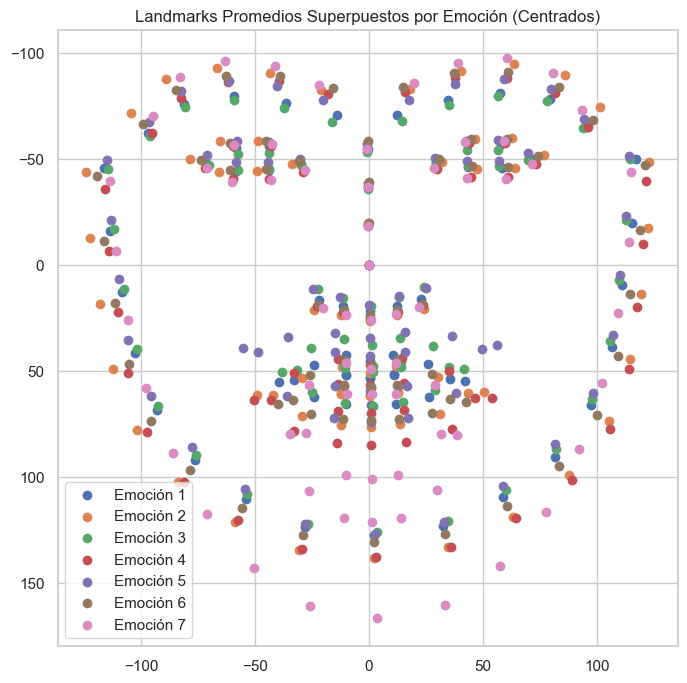

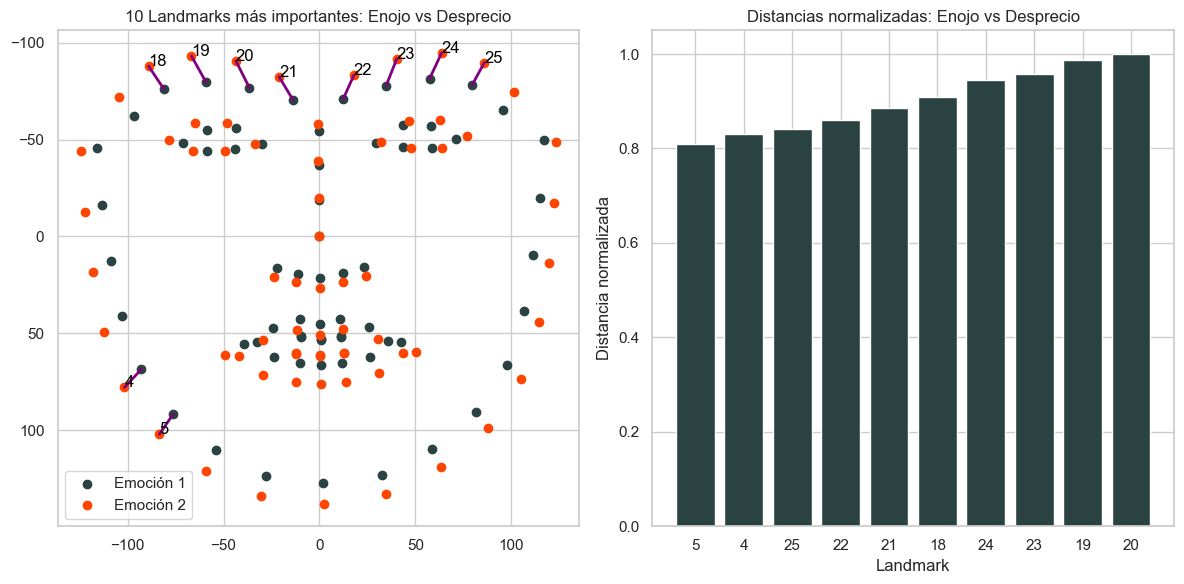

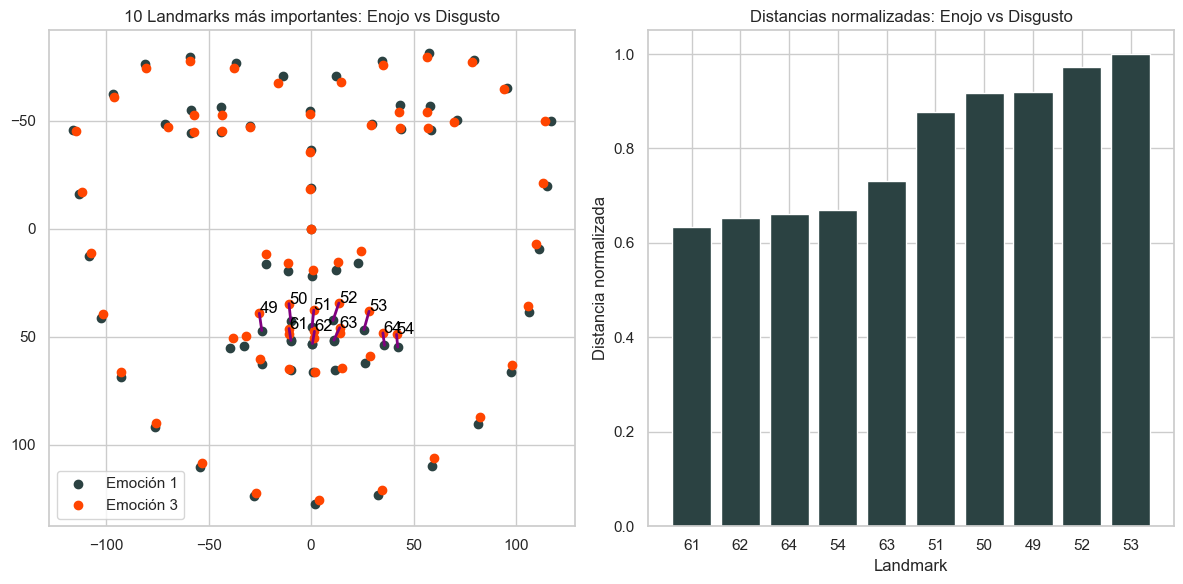

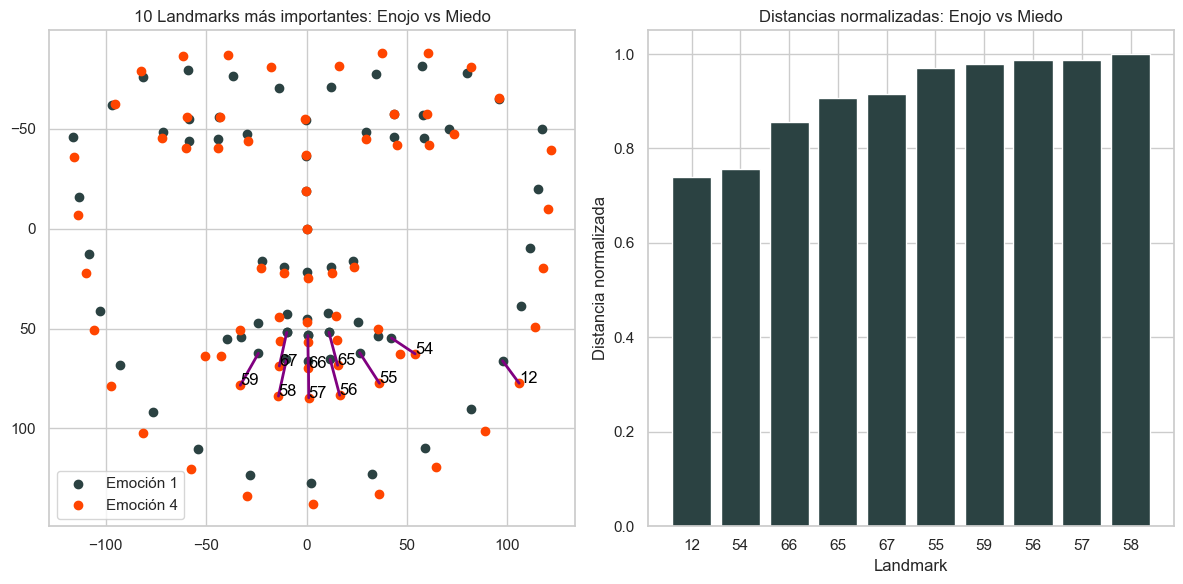

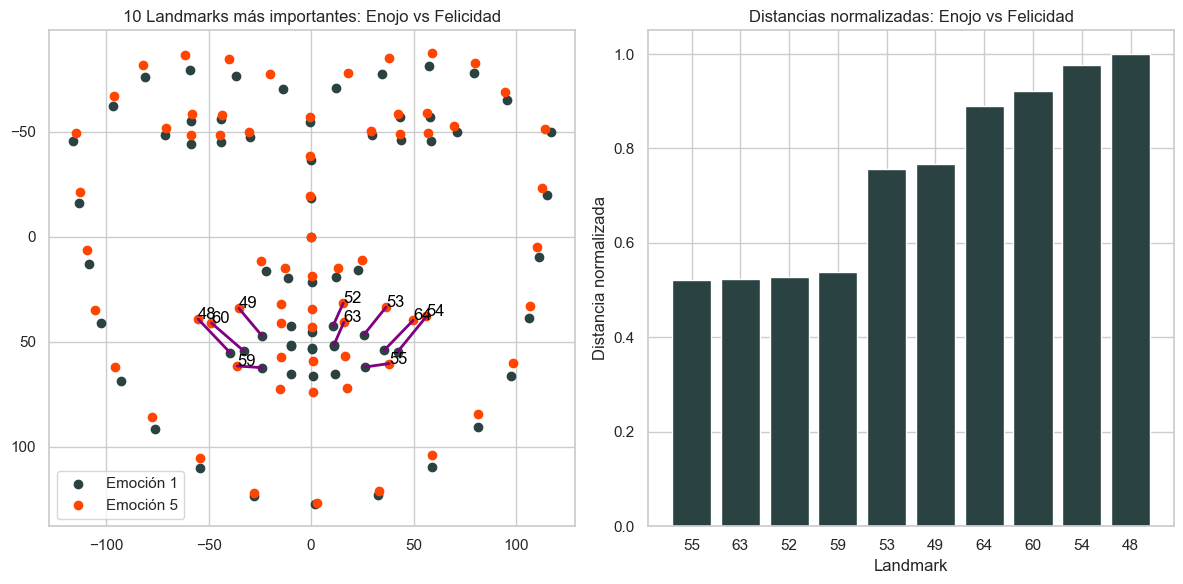

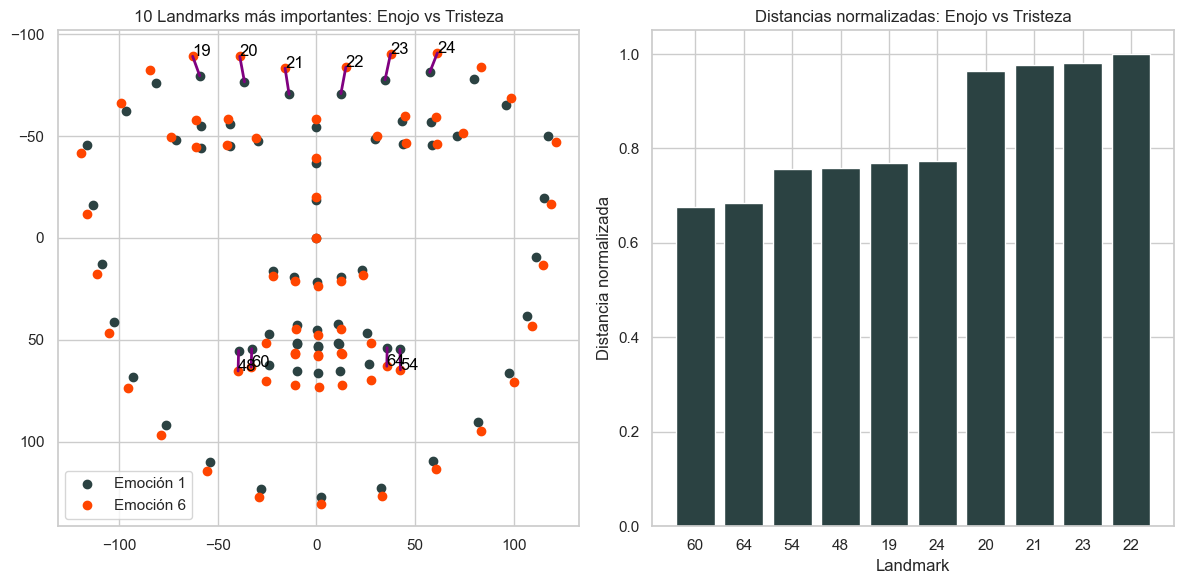

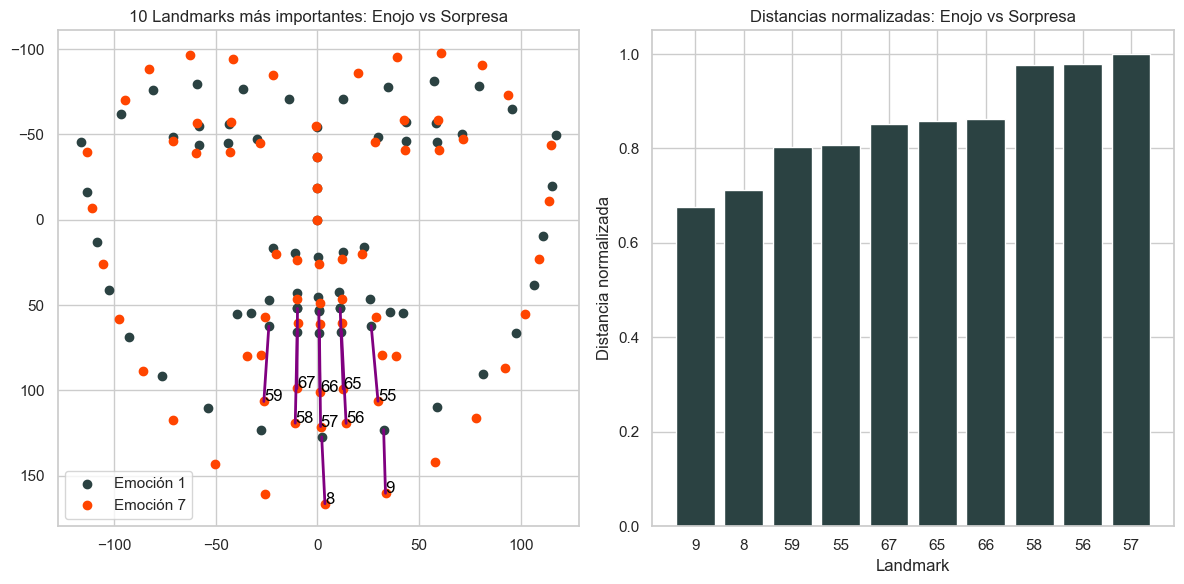

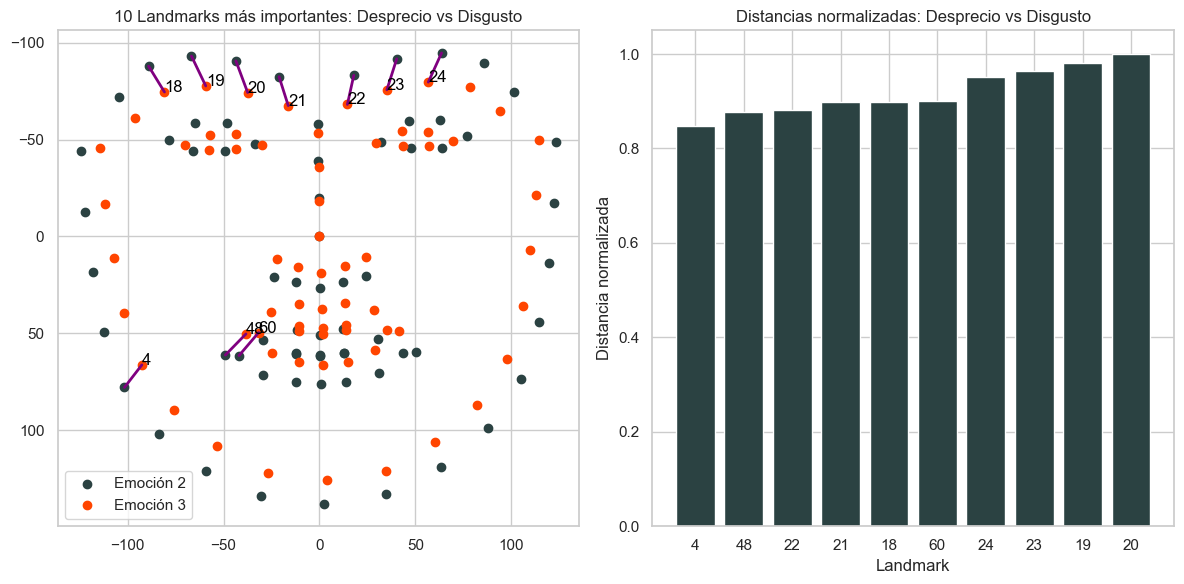

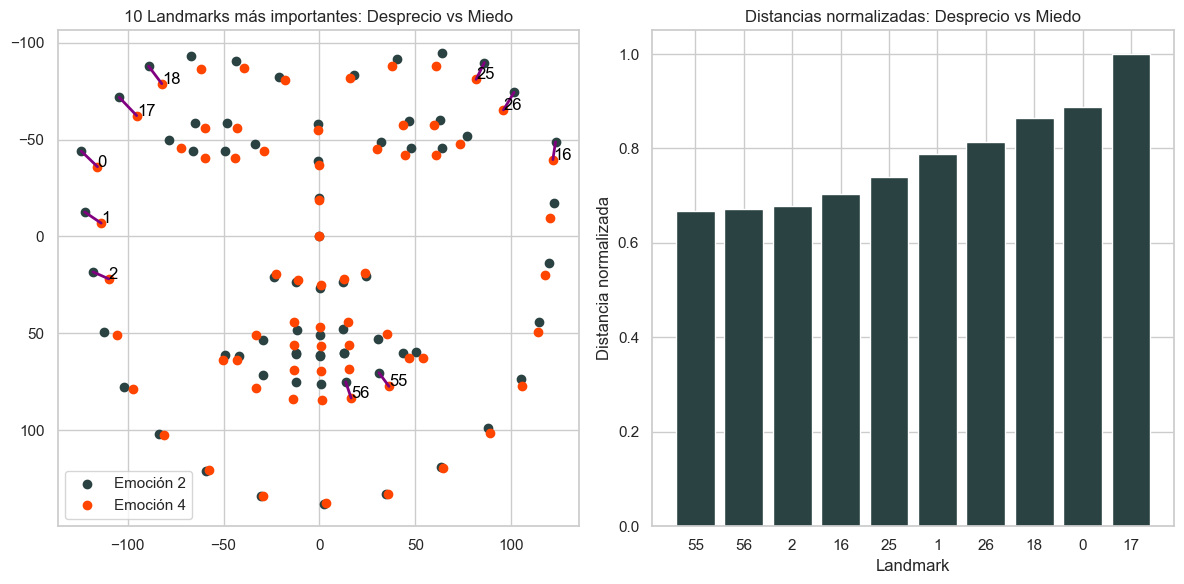

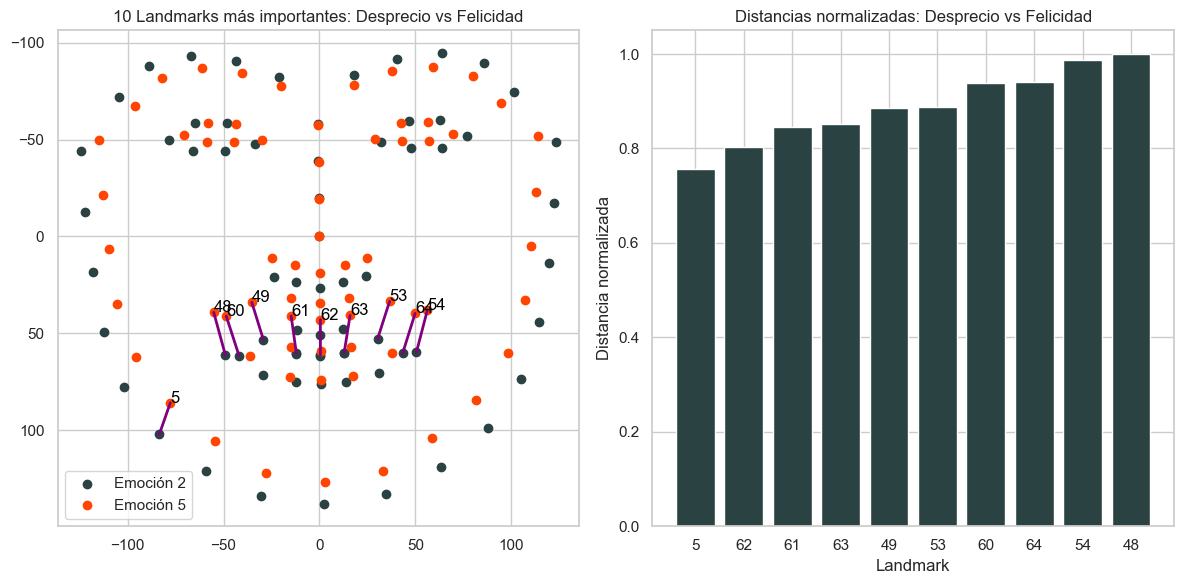

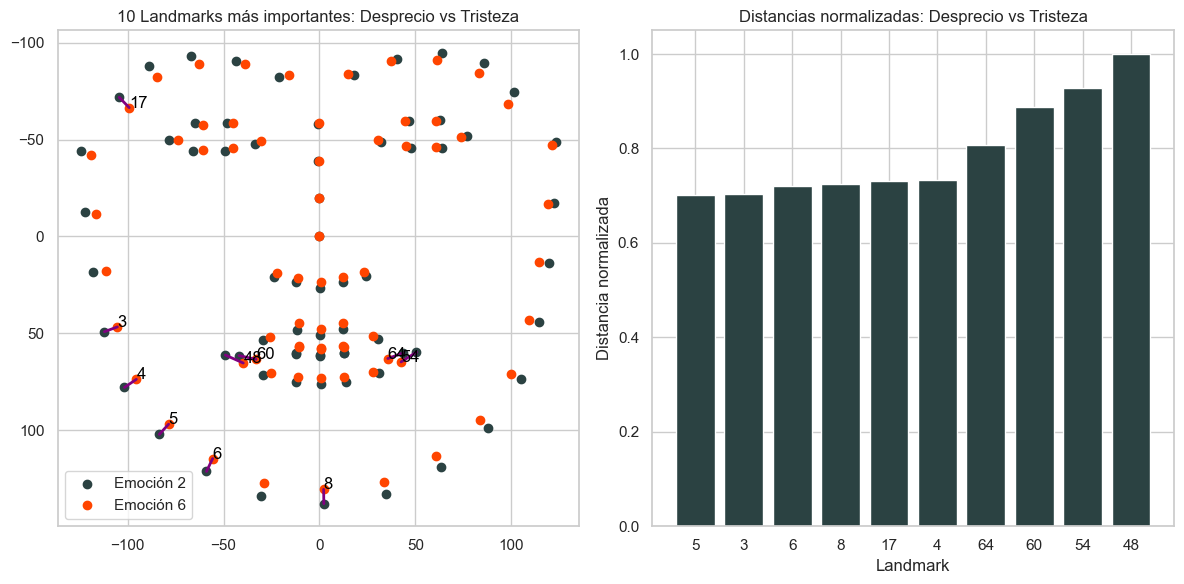

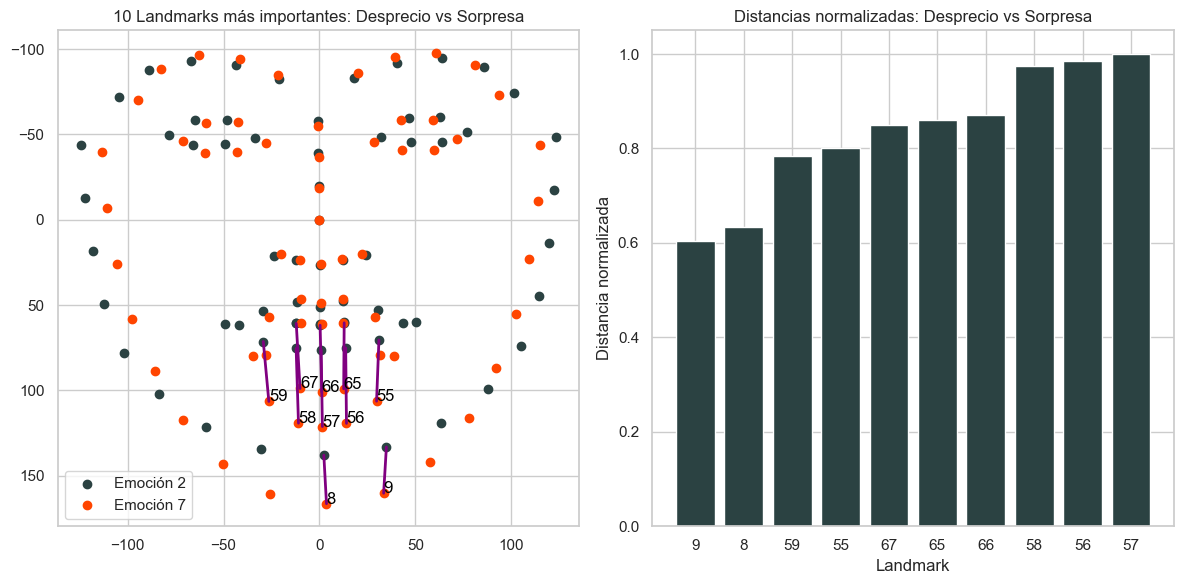

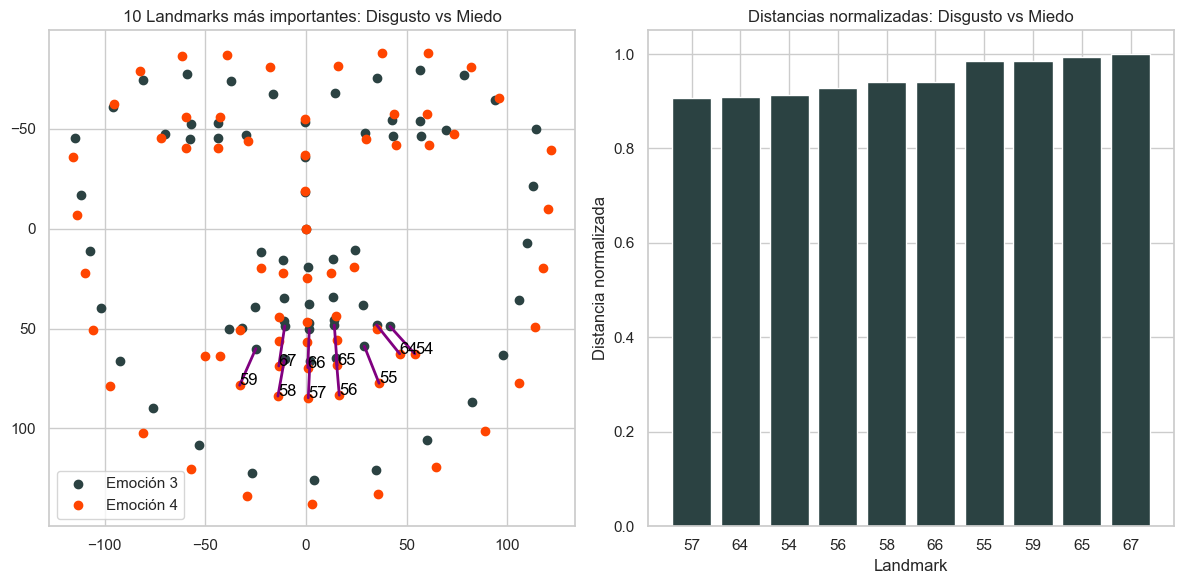

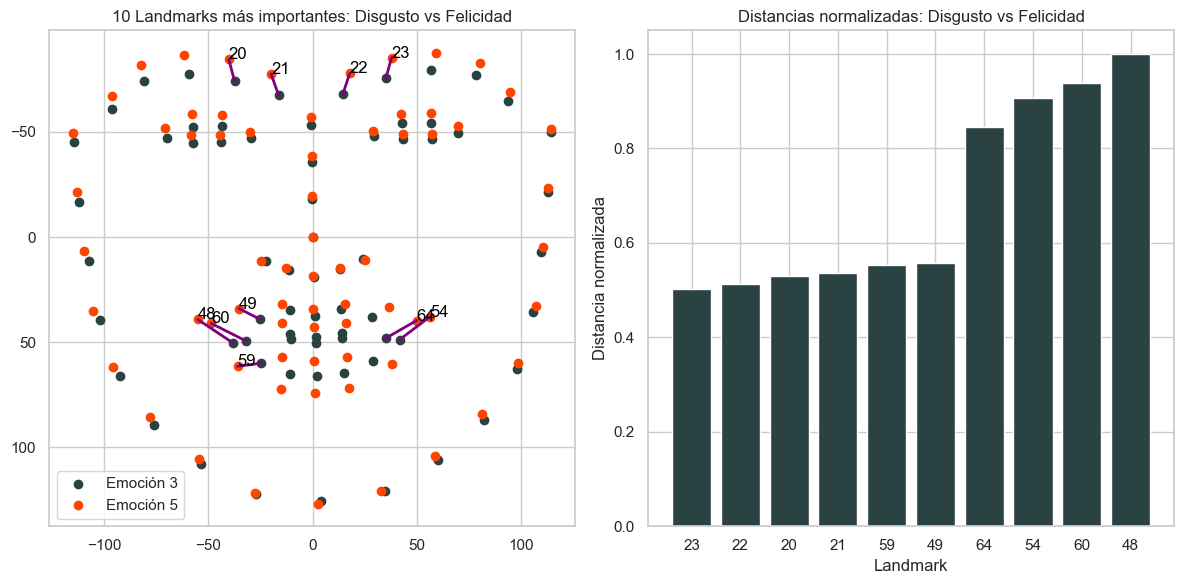

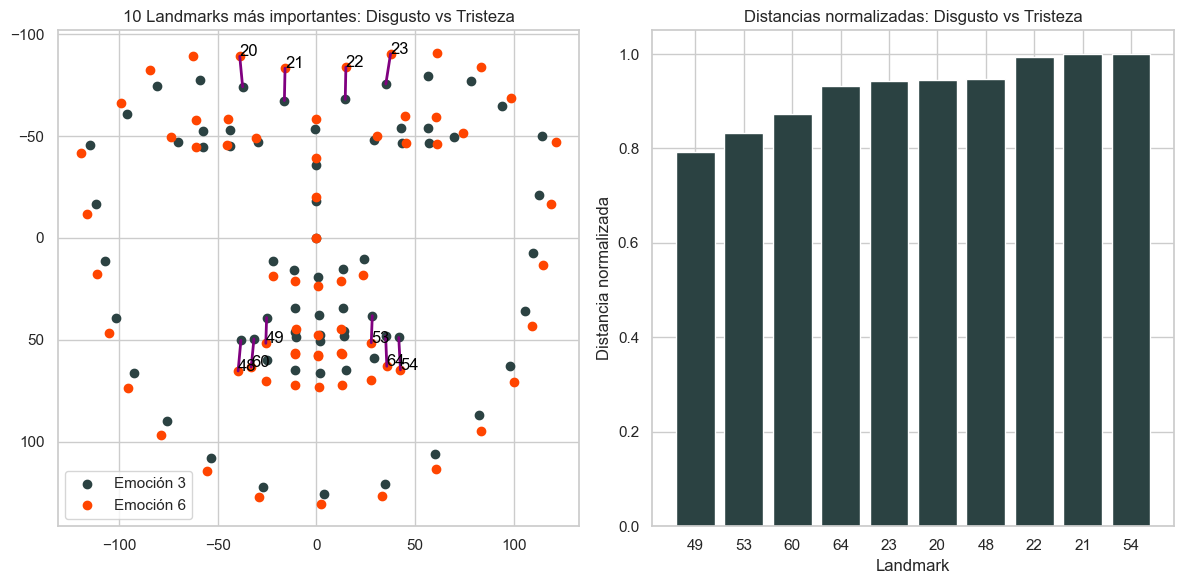

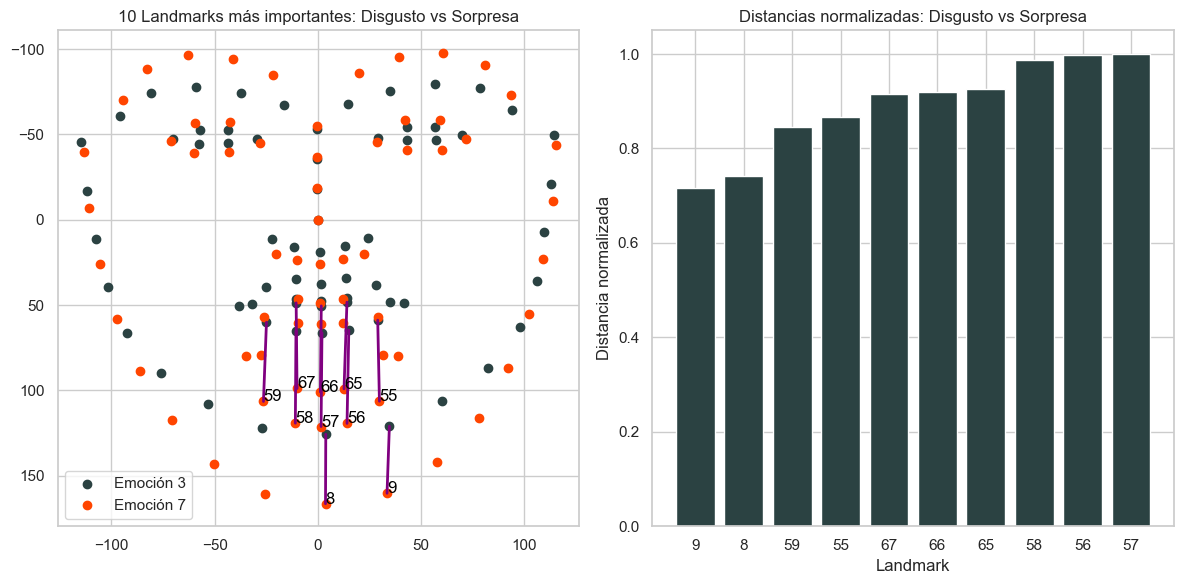

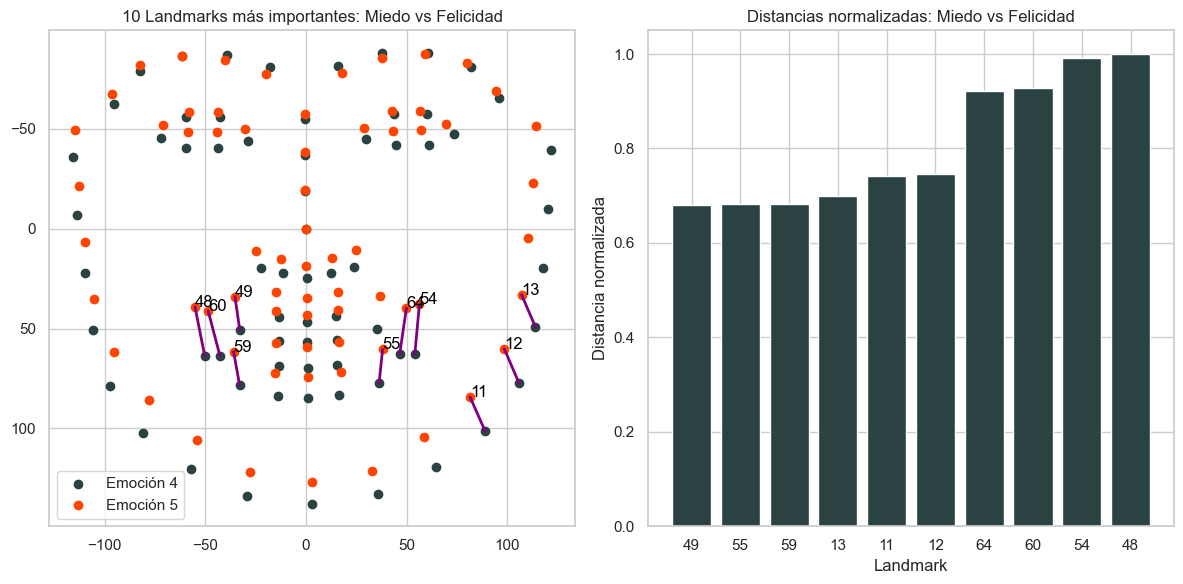

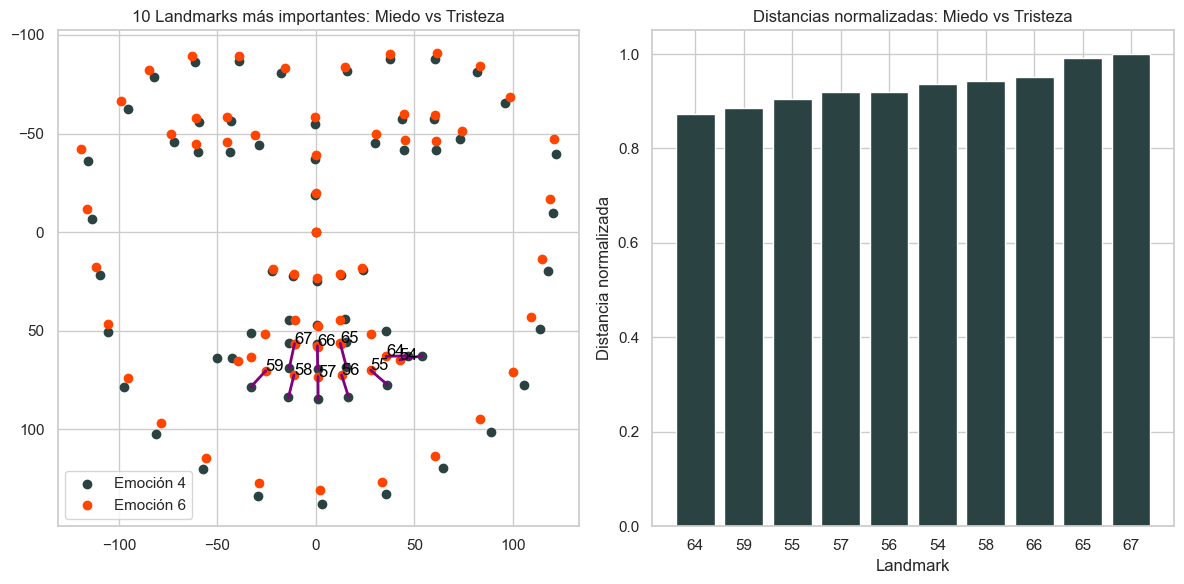

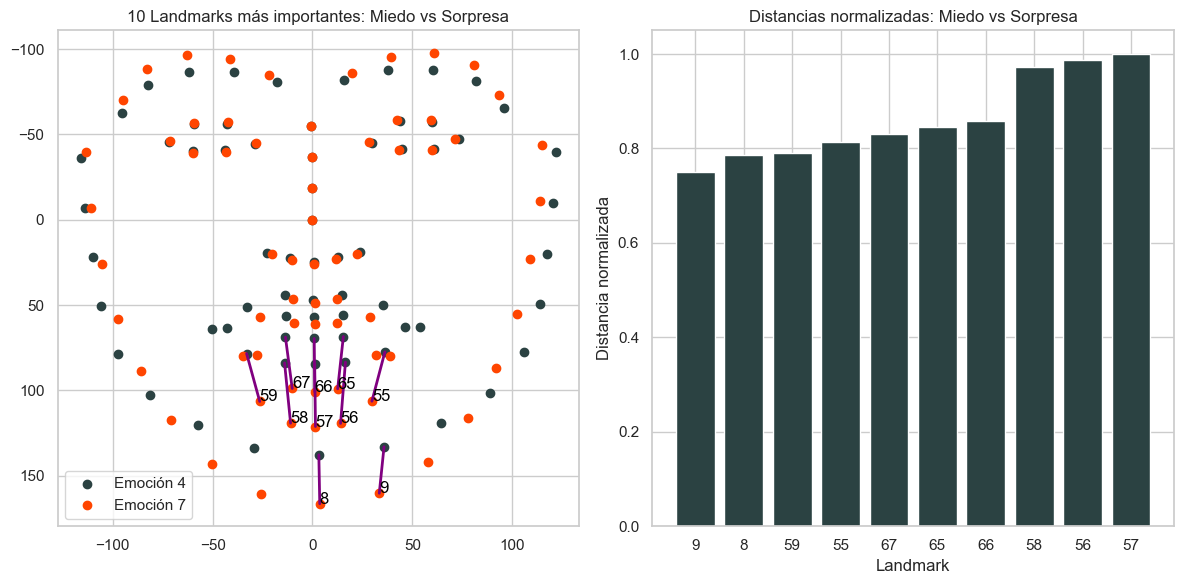

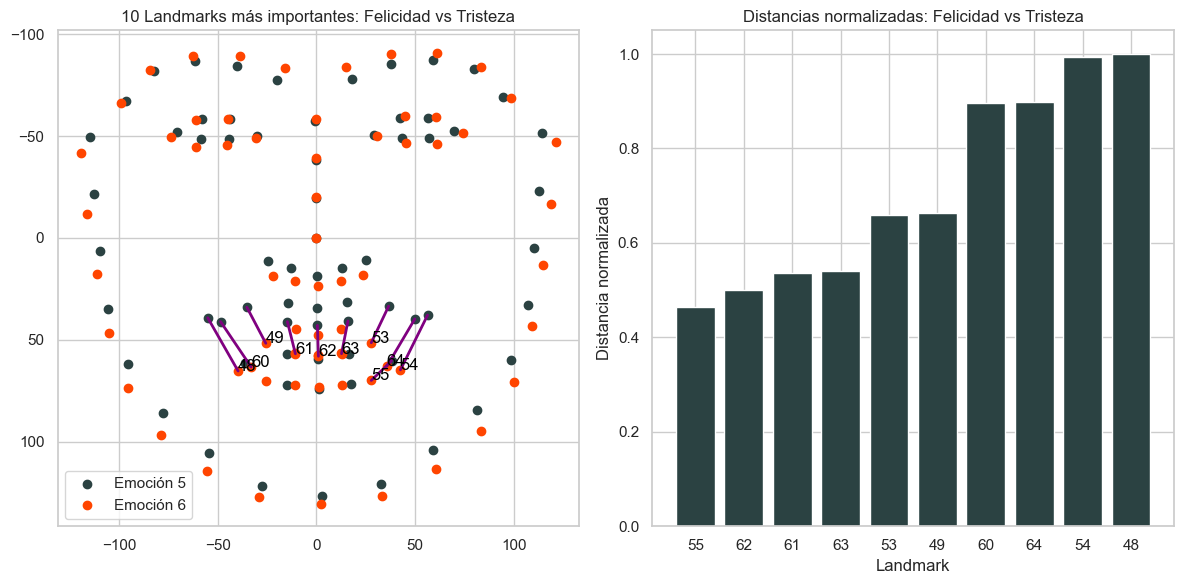

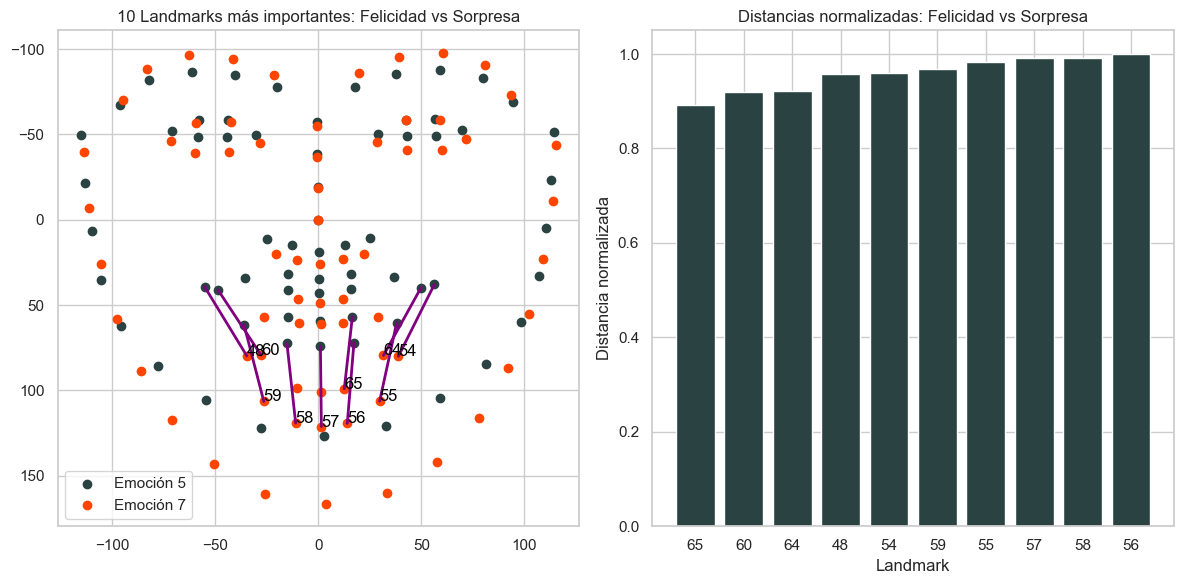

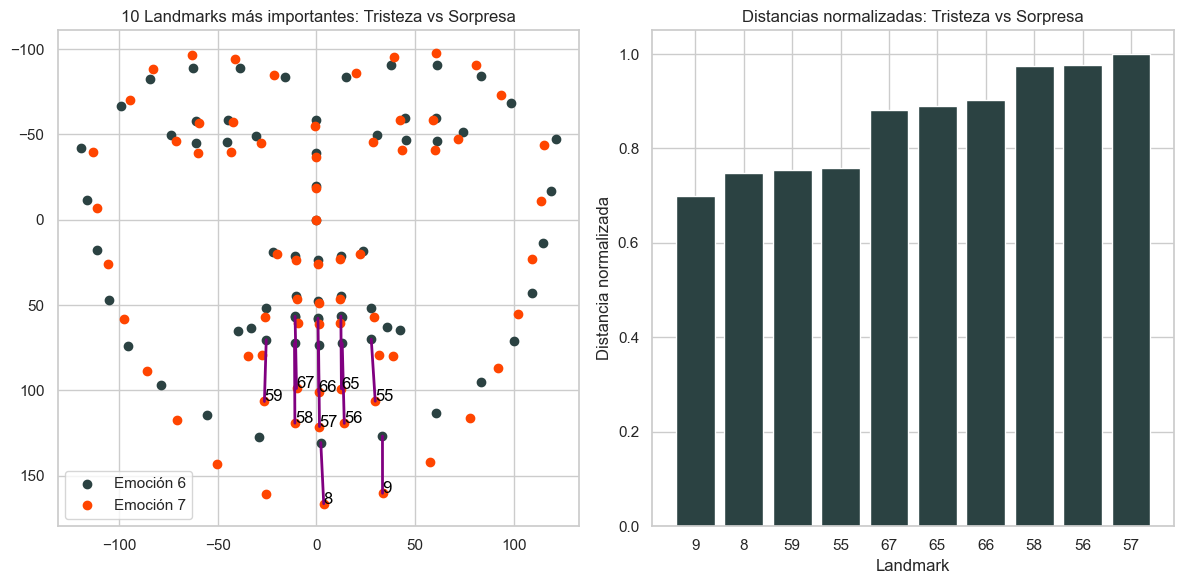

In [6]:
# Inicializar el detector de rostros y el predictor de landmarks
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Función para ordenar numéricamente los archivos
def numerical_sort(value):
    numbers = re.compile(r'(\d+)')
    parts = numbers.split(value)
    parts[1::2] = map(int, parts[1::2])
    return parts

# Función para leer los archivos .txt y obtener las rutas de las imágenes y las emociones
def collect_txt_data(root_dir):
    data = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        dirnames.sort(key=numerical_sort)
        filenames.sort()
        for filename in filenames:
            if filename.endswith('.txt'):
                filepath = os.path.join(dirpath, filename)
                try:
                    with open(filepath, 'r') as f:
                        number = int(float(f.read().strip()))
                    img_path = os.path.join(dirpath, filename).replace('Emotion', 'cohn-kanade-images').replace('_emotion.txt', '.png')
                    if os.path.exists(img_path):  # Verificar si la imagen existe
                        data.append((img_path, number))  # Guardar la ruta de la imagen y la emoción
                except Exception as e:
                    print(f"Error al procesar {filepath}: {e}")
    return data

# Función para detectar y devolver los landmarks de una imagen 
def obtener_landmarks(img_path):
    img = cv2.imread(img_path)
    rostros = detector(img)  
    if len(rostros) == 0:
        return None
    for rostro in rostros:
        landmarks = predictor(img, rostro)
        puntos = np.array([(landmarks.part(n).x, landmarks.part(n).y) for n in range(68)])
        return puntos

# Función para ajustar los landmarks centrando la nariz (landmark 30)
def ajustar_landmarks(landmarks):
    nariz = landmarks[30]  
    landmarks_ajustados = landmarks - nariz  
    return landmarks_ajustados

# Función para calcular el promedio de los landmarks por emoción
def promediar_landmarks(emotion_data):
    suma_landmarks = np.zeros((68, 2))  # 68 puntos (x, y)
    num_imagenes = 0
    
    for img_path in emotion_data:
        landmarks = obtener_landmarks(img_path)
        if landmarks is not None:
            landmarks_ajustados = ajustar_landmarks(landmarks)  
            suma_landmarks += landmarks_ajustados
            num_imagenes += 1
    
    if num_imagenes > 0:
        return suma_landmarks / num_imagenes  
    else:
        return None

# Función para calcular las distancias entre landmarks de diferentes emociones
def calcular_distancias(promedios):
    distancias = {}
    emociones = list(promedios.keys())
    
    for i in range(len(emociones)):
        for j in range(i + 1, len(emociones)):
            emocion1 = emociones[i]
            emocion2 = emociones[j]
            landmarks1 = promedios[emocion1]
            landmarks2 = promedios[emocion2]
            
            # Calcular las distancias entre los mismos landmarks
            distancias_entre_emociones = np.linalg.norm(landmarks1 - landmarks2, axis=1)
            distancias[(emocion1, emocion2)] = distancias_entre_emociones
    
    return distancias

# Función para estandarizar las distancias utilizando Min-Max Scaling
def estandarizar_distancias(distancias):
    scaler = MinMaxScaler()
    
    # Normalizar todas las distancias a un rango de 0 a 1
    for key, dists in distancias.items():
        distancias[key] = scaler.fit_transform(dists.reshape(-1, 1)).flatten()
    
    return distancias
    
# Función para mostrar las distancias más significativas y graficarlas junto a los landmarks
def mostrar_landmarks_importantes(distancias, promedios, n_top=10):
    for (emocion1, emocion2), dists in distancias.items():
        top_indices = np.argsort(dists)[-n_top:]  # Obtener los índices de las distancias más grandes
        #print(f"Emoción {emocion1} vs {emocion2}:")
        
        for idx in top_indices:
            dist = dists[idx]
        
        # Crear figura con dos subplots: uno para los landmarks y otro para la gráfica de barras
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) 
        
        # Visualizar los landmarks que más cambian en ax1
        ax1.scatter(promedios[emocion1][:, 0], promedios[emocion1][:, 1], color='#2B4242', label=f'Emoción {emocion1}')
        ax1.scatter(promedios[emocion2][:, 0], promedios[emocion2][:, 1], color='Orangered', label=f'Emoción {emocion2}')
        
        # Resaltar las líneas que conectan los 10 landmarks más importantes
        for idx in top_indices:
            ax1.plot([promedios[emocion1][idx, 0], promedios[emocion2][idx, 0]], 
                     [promedios[emocion1][idx, 1], promedios[emocion2][idx, 1]], 
                     color='purple', linewidth=2)  
            # Anotar el índice del landmark más importante
            ax1.text(promedios[emocion2][idx, 0], promedios[emocion2][idx, 1], str(idx), fontsize=12, color='black')

        ax1.legend()
        ax1.set_title(f"10 Landmarks más importantes: {emociones[emocion1]} vs {emociones[emocion2]}")  
        ax1.invert_yaxis()

        # Graficar las distancias en barras 
        ax2.bar(range(n_top), dists[top_indices], color='#2B4242')  
        ax2.set_xticks(range(n_top))  
        ax2.set_xticklabels(top_indices) 
        ax2.set_title(f"Distancias normalizadas: {emociones[emocion1]} vs {emociones[emocion2]}")  
        ax2.set_xlabel("Landmark")
        ax2.set_ylabel("Distancia normalizada")
        
        # Mostrar la figura con ambas visualizaciones
        plt.tight_layout()
        plt.show()

# Función para visualizar los landmarks promedio y superponerlos por emoción
def visualizar_landmarks_superpuestos(txt_data):
    emociones_landmarks = {i: [] for i in range(8)}  
    promedios = {}

    # Clasificar las imágenes por emoción
    for img_path, emocion in txt_data:
        emociones_landmarks[emocion].append(img_path)

    # Visualizar los landmarks promedio superpuestos para cada emoción
    plt.figure(figsize=(8, 8)) 
    for emocion, img_paths in emociones_landmarks.items():
        promedio_landmarks = promediar_landmarks(img_paths)
        if promedio_landmarks is not None:
            promedios[emocion] = promedio_landmarks
            plt.scatter(promedio_landmarks[:, 0], promedio_landmarks[:, 1], label=f'Emoción {emocion}')

    # Visualizar todos los landmarks superpuestos
    plt.legend()
    plt.title("Landmarks Promedios Superpuestos por Emoción (Centrados)")
    plt.gca().invert_yaxis()
    plt.show()
    
    return promedios

# Directorios para emociones y las imágenes
root_directory = "Emotion"
txt_data = collect_txt_data(root_directory)

# Verificar si hay datos de emociones
if txt_data:
    promedios = visualizar_landmarks_superpuestos(txt_data)
    
    # Calcular las distancias entre emociones
    distancias = calcular_distancias(promedios)
    
    # Estandarizar las distancias para hacerlas comparables
    distancias_estandarizadas = estandarizar_distancias(distancias)
    
    # Mostrar los 10 landmarks más importantes
    mostrar_landmarks_importantes(distancias_estandarizadas, promedios)
else:
    print("No se encontraron datos de emociones para procesar.")


In [8]:
import torch
import numpy as np
from sklearn.manifold import TSNE, Isomap
import matplotlib.pyplot as plt

def extraer_landmarks_y_emociones(datos_txt):
    # Crear listas para landmarks y emociones
    landmarks_list = []
    emociones_list = []

    for item in datos_txt:
        # Verificar que el elemento tenga exactamente tres valores (dos rutas de imagen y emoción)
        if len(item) == 3:
            ruta_img_inicio, ruta_img_fin, emo = item
            pts = extraer_puntos(ruta_img_fin)  # Usar la última imagen para extraer los puntos
            if pts:
                pts_cen = centrar_puntos(pts)
                # Añadir puntos centrados y emoción correspondiente
                landmarks_list.append(pts_cen)
                emociones_list.append(emo)
        else:
            print(f"Elemento ignorado debido a formato inesperado: {item}")

    # Verificar si se encontraron landmarks válidos
    if not landmarks_list:
        print("No se encontraron landmarks válidos.")
        return None, None

    # Convertir a tensor y array numpy
    landmarks_tensor = torch.tensor(landmarks_list, dtype=torch.float32)
    emociones_array = np.array(emociones_list)

    return landmarks_tensor, emociones_array

# Modificar la función para verificar si landmarks_tensor está vacío
def aplicar_reduccion_dimensionalidad(landmarks_tensor):
    if landmarks_tensor is None or landmarks_tensor.numel() == 0:
        print("No hay datos de landmarks para aplicar t-SNE e Isomap.")
        return None, None

    # Aplanar los landmarks para aplicar t-SNE e Isomap
    flat_landmarks = landmarks_tensor.view(landmarks_tensor.shape[0], -1).numpy()

    # Aplicar t-SNE
    tsne = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=30)
    tsne_resultados = tsne.fit_transform(flat_landmarks)

    # Aplicar Isomap
    isomap = Isomap(n_components=2, n_neighbors=5)
    isomap_resultados = isomap.fit_transform(flat_landmarks)

    return tsne_resultados, isomap_resultados

# Directorio de emociones e imágenes
dir_emo = "Emotion"
datos_txt = obtener_datos_txt(dir_emo)

if datos_txt:
    # Extraer landmarks y emociones
    landmarks_tensor, emociones_array = extraer_landmarks_y_emociones(datos_txt)

    if landmarks_tensor is not None:
        # Aplicar t-SNE e Isomap
        tsne_resultados, isomap_resultados = aplicar_reduccion_dimensionalidad(landmarks_tensor)

        if tsne_resultados is not None and isomap_resultados is not None:
            # Graficar los resultados
            graficar_resultados(tsne_resultados, isomap_resultados, emociones_array)
else:
    print("No se encontraron datos de emociones para procesar.")


No se encontraron imágenes en cohn-kanade-images/S005/001/.ipynb_checkpoints


NameError: name 'graficar_resultados' is not defined